# Computational Linear Algebra: PCA Homework

## Initialization:
Fill the missing values in this text box and in the following code-cell.

**Academic Year:** 2024/2025

### Team Members (Alphabetical Order):
1. Surname1, Name1 (StudentID1);
2. Surname2, Name2 (StudentID2).

In [1]:
StudentID1 = 337728  # <-------- Fill in the missing value
StudentID2 = 334202  # <-------- Fill in the missing value

## Starting Code-Cell 
### Attention: DO NOT CHANGE THE CODE INSIDE THE FOLLOWING CELL!

In [2]:
####################################################################
############## DO NOT CHANGE THE CODE IN THIS CELL #################
####################################################################

import numpy as np

var_entertainment_feat_types = ['Interests', 'Movies', 'Music']
var_personal_feat_types = ['Finance', 'Phobias']
fixed_feat_types = ['Personality', 'Health']

label_types = ['Demographic']

variables_by_type = {
    'Demographics': ['Age', 'Height', 'Weight', 'Number of siblings', 
                     'Gender', 'Hand', 'Education', 'Only child', 'Home Town Type',
                     'Home Type'],
    'Finance': ['Finances', 'Shopping centres', 'Branded clothing', 
                'Entertainment spending', 'Spending on looks', 
                'Spending on gadgets', 'Spending on healthy eating'],
    'Health': ['Smoking', 'Alcohol', 'Healthy eating'],
    'Interests': ['History', 'Psychology', 'Politics', 'Mathematics', 
                  'Physics', 'Internet', 'PC', 'Economy Management', 
                  'Biology', 'Chemistry', 'Reading', 'Geography', 
                  'Foreign languages', 'Medicine', 'Law', 'Cars', 
                  'Art exhibitions', 'Religion', 'Countryside, outdoors', 
                  'Dancing', 'Musical instruments', 'Writing', 'Passive sport', 
                  'Active sport', 'Gardening', 'Celebrities', 'Shopping', 
                  'Science and technology', 'Theatre', 'Fun with friends', 
                  'Adrenaline sports', 'Pets'],
    'Movies': ['Movies', 'Horror', 'Thriller', 'Comedy', 'Romantic', 
               'Sci-fi', 'War', 'Fantasy/Fairy tales', 'Animated', 
               'Documentary', 'Western', 'Action'],
    'Music': ['Music', 'Slow songs or fast songs', 'Dance', 'Folk', 
              'Country', 'Classical music', 'Musical', 'Pop', 'Rock', 
              'Metal or Hardrock', 'Punk', 'Hiphop, Rap', 'Reggae, Ska', 
              'Swing, Jazz', 'Rock n roll', 'Alternative', 'Latino', 
              'Techno, Trance', 'Opera'],
    'Personality': ['Daily events', 'Prioritising workload', 
                    'Writing notes', 'Workaholism', 'Thinking ahead', 
                    'Final judgement', 'Reliability', 'Keeping promises', 
                    'Loss of interest', 'Friends versus money', 'Funniness', 
                    'Fake', 'Criminal damage', 'Decision making', 'Elections', 
                    'Self-criticism', 'Judgment calls', 'Hypochondria', 
                    'Empathy', 'Eating to survive', 'Giving', 
                    'Compassion to animals', 'Borrowed stuff', 
                    'Loneliness', 'Cheating in school', 'Health', 
                    'Changing the past', 'God', 'Dreams', 'Charity', 
                    'Number of friends', 'Punctuality', 'Lying', 'Waiting', 
                    'New environment', 'Mood swings', 'Appearence and gestures', 
                    'Socializing', 'Achievements', 'Responding to a serious letter', 
                    'Children', 'Assertiveness', 'Getting angry', 
                    'Knowing the right people', 'Public speaking', 
                    'Unpopularity', 'Life struggles', 'Happiness in life', 
                    'Energy levels', 'Small - big dogs', 'Personality', 
                    'Finding lost valuables', 'Getting up', 'Interests or hobbies', 
                    "Parents' advice", 'Questionnaires or polls', 'Internet usage'],
    'Phobias': ['Flying', 'Storm', 'Darkness', 'Heights', 'Spiders', 'Snakes', 
                'Rats', 'Ageing', 'Dangerous dogs', 'Fear of public speaking']
}

labels = variables_by_type['Demographics']

try:
    random_seed = min([StudentID1, StudentID2])
except NameError:
    random_seed = StudentID1

def which_featgroups():
    np.random.seed(random_seed)
    these_entertainments = np.random.choice(var_entertainment_feat_types, 2, replace=False).tolist()
    these_personal = np.random.choice(var_personal_feat_types, 1, replace=False).tolist()
    these_types = fixed_feat_types + these_personal + these_entertainments
    print('*** THESE ARE THE SELECTED TYPE OF VARIABLES:')
    for k in these_types:
        print(f'{k}')
    print('*************************************')
    return these_types

def which_features(these_types):
    np.random.seed(random_seed)
    these_features = []
    for type in these_types:
        if type != 'Personality':
            these_features += variables_by_type[type]
        else:
            these_features += np.random.choice(variables_by_type[type], 
                                               int(2 * (len(variables_by_type[type]) / 3)), 
                                               replace=False).tolist()
    print('*** THESE ARE THE SELECTED FEATURES:')
    for ft in these_features:
        print(f'{ft}')
    print('*************************************')
    return these_features

these_types = which_featgroups()
these_features = which_features(these_types)

np.random.seed(random_seed)

*** THESE ARE THE SELECTED TYPE OF VARIABLES:
Personality
Health
Phobias
Music
Interests
*************************************
*** THESE ARE THE SELECTED FEATURES:
Giving
Internet usage
God
Loss of interest
Unpopularity
Writing notes
Self-criticism
Finding lost valuables
Dreams
Workaholism
Energy levels
Parents' advice
Small - big dogs
Interests or hobbies
Lying
Borrowed stuff
Personality
Mood swings
Punctuality
Friends versus money
Decision making
Responding to a serious letter
Judgment calls
Reliability
Socializing
Achievements
Happiness in life
Changing the past
Daily events
New environment
Assertiveness
Elections
Hypochondria
Children
Compassion to animals
Loneliness
Fake
Empathy
Smoking
Alcohol
Healthy eating
Flying
Storm
Darkness
Heights
Spiders
Snakes
Rats
Ageing
Dangerous dogs
Fear of public speaking
Music
Slow songs or fast songs
Dance
Folk
Country
Classical music
Musical
Pop
Rock
Metal or Hardrock
Punk
Hiphop, Rap
Reggae, Ska
Swing, Jazz
Rock n roll
Alternative
Latino
Techno,

## Importing Modules

In the following cell, import all the modules you think are necessary for doing the homework, **among the ones listed and used during the laboratories of the course**.
No extra modules are allowed for reproducibility.

In [3]:
# DO NOT IMPORT NUMPY
%matplotlib widget
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
from IPython.display import display  # to display variables in a "nice" way

pd.options.mode.copy_on_write = True

## Exercise 1. Preparing the Dataset

In the cells below, do the following operations:
1. load the dataset "_responses_hw.csv_";
2. create a working dataframe extracting from _responses_hw.csv_ the columns corresponding to the variables in _these_features_, and randomly selecting 2/3 of the rows. Let us call this dataframe _X_df_;
3. analyze the obtained dataframe and performing cleansing/encoding operations.

We first proceed by extracting the data from the csv file

In [4]:
df = pd.read_csv('responses_hw.csv')

Then we continue by retaining only columns of our interest

In [5]:
X_df = df[these_features + labels]

From such data, we sample 2/3 of it to reduce the size of the problem

In [6]:
X_df = X_df.sample(frac=2/3, random_state=random_seed)

In [7]:
X_df

,Giving,Internet usage,God,Loss of interest,Unpopularity,Writing notes,Self-criticism,Finding lost valuables,Dreams,Workaholism,...,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
833,1.0,few hours a day,1.0,5.0,3.0,1.0,4.0,1.0,3,2.0,...,19.0,193.0,77.0,1.0,male,right,secondary school,yes,city,block of flats
663,3.0,no time at all,3.0,3.0,3.0,3.0,3.0,3.0,3,3.0,...,25.0,191.0,77.0,1.0,male,right,masters degree,no,city,house/bungalow
622,5.0,few hours a day,1.0,1.0,5.0,5.0,5.0,2.0,4,4.0,...,18.0,161.0,74.0,1.0,female,right,primary school,no,city,block of flats
636,2.0,few hours a day,5.0,5.0,3.0,3.0,4.0,3.0,3,3.0,...,24.0,171.0,93.0,2.0,male,right,doctorate degree,no,village,house/bungalow
431,3.0,few hours a day,3.0,2.0,3.0,3.0,3.0,1.0,4,3.0,...,19.0,185.0,78.0,2.0,male,left,secondary school,no,village,house/bungalow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
807,2.0,few hours a day,4.0,3.0,3.0,1.0,3.0,2.0,3,2.0,...,20.0,187.0,95.0,0.0,male,right,secondary school,yes,city,block of flats
984,2.0,most of the day,1.0,4.0,3.0,1.0,1.0,4.0,2,1.0,...,21.0,165.0,55.0,1.0,female,right,secondary school,yes,city,block of flats
41,1.0,few hours a day,3.0,5.0,5.0,4.0,5.0,1.0,4,4.0,...,20.0,188.0,80.0,3.0,male,right,college/bachelor degree,no,city,block of flats
610,2.0,few hours a day,2.0,4.0,4.0,2.0,5.0,3.0,3,2.0,...,20.0,183.0,83.0,1.0,male,right,secondary school,no,city,house/bungalow


We can briefly have a view of such dataframe meta-data

In [8]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 673 entries, 833 to 607
Columns: 112 entries, Giving to Home Type
dtypes: float64(99), int64(2), object(11)
memory usage: 594.1+ KB


Concerning missing data, in the rows and columns of the dataframe we find that:

- We have a total of 189 rows presenting at least one missing value

In [9]:
null_counts = X_df.isnull().sum(axis=1)
null_counts = null_counts[null_counts > 0]
print(null_counts.sort_values()[::-1])
print("\nMax numb of null in rows:", null_counts.max())

174    6
137    6
330    5
368    5
777    4
      ..
843    1
56     1
270    1
289    1
607    1
Length: 189, dtype: int64

Max numb of null in rows: 6


- We have a total of 100 features (on 112) presenting at least one missing value

In [10]:
null_counts = X_df.isnull().sum(axis=0)
null_counts = null_counts[null_counts > 0]
print(null_counts.sort_values()[::-1])
print("\nMax numb of null in columns:", null_counts.max())

Height               14
Weight               12
Passive sport         8
Chemistry             7
Latino                6
                     ..
New environment       1
Adrenaline sports     1
Achievements          1
Happiness in life     1
Decision making       1
Length: 100, dtype: int64

Max numb of null in columns: 14


We are not going to fill-in missing data with placeholders because there is no obvious, neutral replacement know apriori. Since we are doing PCA first, followed by KMeans clustering, we decided to delete rows with missing data. This is justified since PCA needs complete and accurate features to work well. KMeans, on the other hand, can handle some missing point as long as the rest of them are reliable.

In [11]:
X_df = X_df.dropna(axis=0)

We can do a double check to verify that such data has been removed

In [12]:
null_counts = X_df.isnull().sum(axis=1)
null_counts = null_counts[null_counts > 0]
print(f'Rows with missing values: {len(null_counts)}')

Rows with missing values: 0


Our dataframe lost roughly ~200 rows (1/3 of the rows) by perfoming this drop.

Usually a good procedure to reduce such high lost of information would be to introduce special features' values represening "unkown information" in some columns. Looking at the chart of top-mising-values features, showed some cells above, we could not find any immediate placeholder, therefore we opted to **not** replace such values and continue with only the remaining data at our disposal.

We will now proceed to divide the dataframe in:
1. Features we will feed to our transformers, PCA and Kmeans objects, i.e. `these_features`;
2. Features which will be used to characterize such data during visualization, i.e. `labels`

In [13]:
X_df_labels = X_df.drop(columns=these_features)
X_df_labels.reset_index(drop=True, inplace=True)

In [14]:
X_df = X_df.drop(columns=labels)
X_df.reset_index(drop=True, inplace=True)

Looking at `X_df` we notice non-coherent data types, we suppose that strings (i.e. `dtype('O')`) are related to categorical features, while the rest are just numerical dimensions mixed between `int` and `float`

In [15]:
X_df.dtypes.unique()

array([dtype('float64'), dtype('O'), dtype('int64')], dtype=object)

To make the data coherent we will convert `int` values in `float`, so that the final dataframe will only be populated by floating point numbers. 

> **Note**
> This is not necessary to make the objects to work properly later, it is just a transformation made on the purpose to make the dataframe at our disposal more coherent and clean

In [16]:
X_df.select_dtypes(include=['int64']).columns

Index(['Dreams', 'Snakes'], dtype='object')

In [17]:
X_df['Dreams'] = X_df['Dreams'].astype(float)

In [18]:
X_df['Snakes'] = X_df['Snakes'].astype(float)

In [19]:
X_df[['Dreams', 'Snakes']]

,Dreams,Snakes
0,3.0,5.0
1,4.0,4.0
2,4.0,4.0
3,4.0,1.0
4,4.0,1.0
...,...,...
479,3.0,2.0
480,3.0,5.0
481,2.0,2.0
482,4.0,1.0


We then proceed to encode non-numerical variables

In [20]:
cat_X_df = X_df.select_dtypes(include=['object'])

In [21]:
cat_X_df

,Internet usage,Lying,Punctuality,Smoking,Alcohol
0,few hours a day,sometimes,on time,current smoker,social drinker
1,few hours a day,only to avoid hurting someone,late,former smoker,drink a lot
2,few hours a day,sometimes,early,tried smoking,never
3,few hours a day,everytime it suits me,late,former smoker,drink a lot
4,few hours a day,everytime it suits me,early,current smoker,drink a lot
...,...,...,...,...,...
479,few hours a day,only to avoid hurting someone,early,tried smoking,never
480,few hours a day,only to avoid hurting someone,early,current smoker,never
481,most of the day,sometimes,late,current smoker,drink a lot
482,few hours a day,never,late,tried smoking,social drinker


In [22]:
cat_X_df['Internet usage'].unique()

array(['few hours a day', 'most of the day', 'less than an hour a day'],
      dtype=object)

In [23]:
cat_X_df['Lying'].unique()

array(['sometimes', 'only to avoid hurting someone',
       'everytime it suits me', 'never'], dtype=object)

In [24]:
cat_X_df['Punctuality'].unique()

array(['on time', 'late', 'early'], dtype=object)

In [25]:
cat_X_df['Smoking'].unique()

array(['current smoker', 'former smoker', 'tried smoking', 'never smoked'],
      dtype=object)

In [26]:
cat_X_df['Alcohol'].unique()

array(['social drinker', 'drink a lot', 'never'], dtype=object)

For this data, we will apply label encoding while preserving the natural order of the values. The objective is to encode the variables following an incremental order, assigned as demonstrated in the following dictonaries. Eventual distortions arised for different ranges of possible numerical values (`1, ..., 3` vs. `1, ..., 5`) will be managed with the scalers in the following lines. We interpreted all the categorical values to be orderable, altought different options could be accepted too (e.g. dummy encoding), for those attributes who does not look imediatelly orderable (e.g. `smoking`).

In [27]:
internet_mapping = {
    'less than an hour a day': 1.0,
    'few hours a day': 2.0,
    'most of the day': 3.0
}

In [28]:
lying_mapping = {
    'never': 1.0,
    'only to avoid hurting someone': 2.0,
    'sometimes': 3.0,
    'everytime it suits me': 4.0
}

In [29]:
punctuality_mapping = {
    'early': 1.0,
    'on time': 2.0,
    'late': 3.0
}

In [30]:
smoking_mapping = {
    'never smoked': 1.0,
    'tried smoking': 2.0,
    'former smoker': 3.0,
    'current smoker': 4.0
}

In [31]:
alcohol_mapping = {
    'never': 1.0,
    'social drinker': 2.0,
    'drink a lot': 3.0
}

In [32]:
X_df['Internet usage']

0      few hours a day
1      few hours a day
2      few hours a day
3      few hours a day
4      few hours a day
            ...       
479    few hours a day
480    few hours a day
481    most of the day
482    few hours a day
483    few hours a day
Name: Internet usage, Length: 484, dtype: object

In [33]:
X_df['Internet usage'] = X_df['Internet usage'].map(internet_mapping)

In [34]:
X_df['Internet usage']

0      2.0
1      2.0
2      2.0
3      2.0
4      2.0
      ... 
479    2.0
480    2.0
481    3.0
482    2.0
483    2.0
Name: Internet usage, Length: 484, dtype: float64

We notice that the mapping actually works, we can then proceed with all other categorical features

In [35]:
X_df['Lying'] = X_df['Lying'].map(lying_mapping)

In [36]:
X_df['Punctuality'] = X_df['Punctuality'].map(punctuality_mapping)

In [37]:
X_df['Smoking'] = X_df['Smoking'].map(smoking_mapping)

In [38]:
X_df['Alcohol'] = X_df['Alcohol'].map(alcohol_mapping)

As a final result we obtain the following data:

In [39]:
X_df

,Giving,Internet usage,God,Loss of interest,Unpopularity,Writing notes,Self-criticism,Finding lost valuables,Dreams,Workaholism,...,Passive sport,Active sport,Gardening,Celebrities,Shopping,Science and technology,Theatre,Fun with friends,Adrenaline sports,Pets
0,1.0,2.0,1.0,5.0,3.0,1.0,4.0,1.0,3.0,2.0,...,4.0,3.0,1.0,1.0,3.0,3.0,5.0,5.0,1.0,1.0
1,5.0,2.0,1.0,1.0,5.0,5.0,5.0,2.0,4.0,4.0,...,5.0,5.0,1.0,1.0,3.0,2.0,4.0,5.0,4.0,5.0
2,3.0,2.0,3.0,2.0,3.0,3.0,3.0,1.0,4.0,3.0,...,4.0,1.0,3.0,2.0,2.0,5.0,4.0,5.0,4.0,3.0
3,2.0,2.0,5.0,1.0,5.0,3.0,5.0,1.0,4.0,4.0,...,5.0,1.0,2.0,1.0,4.0,3.0,1.0,5.0,4.0,2.0
4,1.0,2.0,1.0,3.0,1.0,4.0,3.0,4.0,4.0,5.0,...,5.0,5.0,1.0,2.0,2.0,4.0,3.0,5.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,4.0,2.0,3.0,2.0,3.0,5.0,3.0,3.0,3.0,4.0,...,4.0,4.0,4.0,1.0,2.0,3.0,3.0,5.0,1.0,5.0
480,2.0,2.0,4.0,3.0,3.0,1.0,3.0,2.0,3.0,2.0,...,4.0,2.0,2.0,3.0,4.0,3.0,4.0,5.0,3.0,5.0
481,2.0,3.0,1.0,4.0,3.0,1.0,1.0,4.0,2.0,1.0,...,3.0,1.0,1.0,1.0,2.0,3.0,5.0,4.0,3.0,4.0
482,1.0,2.0,3.0,5.0,5.0,4.0,5.0,1.0,4.0,4.0,...,1.0,5.0,1.0,1.0,1.0,3.0,1.0,5.0,5.0,3.0


In [40]:
X_df_labels

,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
0,19.0,193.0,77.0,1.0,male,right,secondary school,yes,city,block of flats
1,18.0,161.0,74.0,1.0,female,right,primary school,no,city,block of flats
2,19.0,185.0,78.0,2.0,male,left,secondary school,no,village,house/bungalow
3,19.0,184.0,60.0,4.0,male,right,college/bachelor degree,no,city,block of flats
4,21.0,183.0,73.0,0.0,female,right,secondary school,yes,city,block of flats
...,...,...,...,...,...,...,...,...,...,...
479,26.0,169.0,70.0,2.0,male,right,masters degree,no,city,house/bungalow
480,20.0,187.0,95.0,0.0,male,right,secondary school,yes,city,block of flats
481,21.0,165.0,55.0,1.0,female,right,secondary school,yes,city,block of flats
482,20.0,188.0,80.0,3.0,male,right,college/bachelor degree,no,city,block of flats


## Exercise 2. Analyzing the Variance and the PCs

In the cells below, do the following operations:
1. create two new dataframes from _X_df_ applying a StandardScaler and a MinMaxscaler. Call these new dataframes as _Xstd_df_ and _Xmm_df_, respectively;
2. compute the variance of all the features in _X_df_, _Xstd_df_, and _Xmm_df_ and **comment the results**;
3. compute all the $n$ Principal Components (PCs) for each dataset _X_df_, _Xstd_df_, and _Xmm_df_. Then, visualize the curves of the cumulative explained variances and **comment the results**.

In [41]:
standardScaler = StandardScaler()
Xstd_df = standardScaler.fit_transform(X_df)

In [42]:
minMaxScaler = MinMaxScaler() 
Xmm_df = minMaxScaler.fit_transform(X_df)

In [43]:
var_X = X_df.var()
print("\nOriginal features variance:")
print(var_X)


Original features variance:
Giving                    1.779559
Internet usage            0.270875
God                       2.192957
Loss of interest          1.774597
Unpopularity              1.276047
                            ...   
Science and technology    1.583265
Theatre                   1.701059
Fun with friends          0.559366
Adrenaline sports         2.020704
Pets                      2.361151
Length: 102, dtype: float64


In [44]:
var_Xstd = np.var(Xstd_df, axis=0)
var_Xstd = pd.Series(var_Xstd, index=var_X.index)
print("\nStandard scaled features variance:")
print(var_Xstd)


Standard scaled features variance:
Giving                    1.0
Internet usage            1.0
God                       1.0
Loss of interest          1.0
Unpopularity              1.0
                         ... 
Science and technology    1.0
Theatre                   1.0
Fun with friends          1.0
Adrenaline sports         1.0
Pets                      1.0
Length: 102, dtype: float64


In [45]:
var_Xmm = np.var(Xmm_df, axis=0)
var_Xmm = pd.Series(var_Xmm, index=var_X.index)
print("\nMin-max scaled features variance:")
print(var_Xmm)


Min-max scaled features variance:
Giving                    0.110993
Internet usage            0.067579
God                       0.136777
Loss of interest          0.110683
Unpopularity              0.079588
                            ...   
Science and technology    0.098750
Theatre                   0.106097
Fun with friends          0.062023
Adrenaline sports         0.126033
Pets                      0.147267
Length: 102, dtype: float64


Analyzing the variance, we notice that the features that present the highest and lowest variance are:

In [46]:
var_X.sort_values()[::-1]

Elections         2.426860
Spiders           2.372444
Pets              2.361151
Active sport      2.326587
Snakes            2.275362
                    ...   
Dreams            0.420559
Personality       0.384182
Music             0.339955
Alcohol           0.315436
Internet usage    0.270875
Length: 102, dtype: float64

While on the min-max scaled data, those features that present the highest and lowest variance are:

In [47]:
var_Xmm.sort_values()[::-1]

Punctuality                 0.152376
Elections                   0.151365
Spiders                     0.147971
Pets                        0.147267
Active sport                0.145111
                              ...   
Happiness in life           0.041839
Slow songs or fast songs    0.039759
Dreams                      0.026231
Personality                 0.023962
Music                       0.021203
Length: 102, dtype: float64

In the original data before normalization we can observe that features representing topics with more divisive opinions or different behaviours among population in society have higher variance (e.g. `Elections` - associated to *"I always try to vote in elections"*, with most of the people either caring a lot about voting or being not used to vote at all).

While features where all people have the same opinions, or behave in a similar way, with a significantly low variance (e.g. `Internet usage` - associated to *"How much time do you spend online?"*, in which we expect people using internet almost always the same amount of time during the day).

After applying the standard scaler, as expected, all the features have the same variance, which is equal to one. Therefore a confront among features looses of meaning.

The MinMaxScaler applies a transformation that maps each feature to a `[0, 1]` range. This scaling reduces the value of variances, *without* preserving the ratios between original features variances (i.e. sorted variances will have a different order). That being said, despite some minor differences, we observe that such scaling preserve almost the whole sorting of such variances.

While this is true for almost all the features, we can notice some that significantly change of position in the charts, take `Punctuality` for instance:

In [48]:
print(f"In X_df Punctuality is placed on the {var_X.rank(ascending=False)['Punctuality']}th spot among {len(var_X)}")

In X_df Punctuality is placed on the 95.0th spot among 102


In [49]:
print(f"In X_mm Punctuality is placed on the {var_Xmm.rank(ascending=False)['Punctuality']}th spot among {len(var_Xmm)}")

In X_mm Punctuality is placed on the 1.0th spot among 102


The reason why `Punctuality` is able to significantly improve its rank in the chart of variance while using the MinMax Scaler comes from both how values of `Punctuality` ranges (with values in `1, 2, 3` rather than `1, ..., 5`) and how the MinMax scaler works.
- A shorter range of values associated to the feature will have the effect to produce a lower variance
- The MinMax scaler on the other hand mitigates this phenomenon my disposing those same values in the whole range [0, 1]

Indeed, `Punctuality` is one of the features we encoded, in the relative cells above we already warned about such effect of a naive incremental label encoding on data. Thanks to the MinMax Scaler such lost information is partially re-extracted giving us a more meaningful insight.

In [50]:
X_df['Punctuality'].unique()

array([2., 3., 1.])

We can further analyze other features with a reduced range of values. For instance `Interet usage`:

In [51]:
X_df['Internet usage'].unique()

array([2., 3., 1.])

Despite the fact that also this feature ranges in such a shorter range of possible values, its position on the variance chart do not improve much

In [52]:
print(f"In X_df Internet usage is placed on the {var_X.rank(ascending=False)['Internet usage']}th spot among {len(var_X)}")

In X_df Internet usage is placed on the 102.0th spot among 102


In [53]:
print(f"In X_mm Internet usage is placed on the {var_Xmm.rank(ascending=False)['Internet usage']}th spot among {len(var_Xmm)}")

In X_mm Internet usage is placed on the 85.0th spot among 102


We will now proceed with the PCA

In [54]:
pca_xdf = PCA()
pca_xdf.fit(X_df)

PCA()

In [55]:
pca_std = PCA()
pca_std.fit(Xstd_df)

PCA()

In [56]:
pca_mm = PCA()
pca_mm.fit(Xmm_df)

PCA()

In [57]:
def plot_cumulative_explained_variance(pca, print_PCs=[1, 20, 40], title=None, xlabel='Principal components', ylabel='Cumulative explained variance'):
    cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)

    for pc in print_PCs:
        pc_index = pc - 1
        print(f"Cumulative explained variance for PC{pc}:\t{cum_explained_variance[pc_index]:.4f}")
    
    plt.figure()
    plt.plot(cum_explained_variance)
    plt.title(title)
    plt.ylim([0, 1.1])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.tight_layout()
    plt.show()

Cumulative explained variance for PC1:	0.0769
Cumulative explained variance for PC20:	0.5495
Cumulative explained variance for PC40:	0.7523


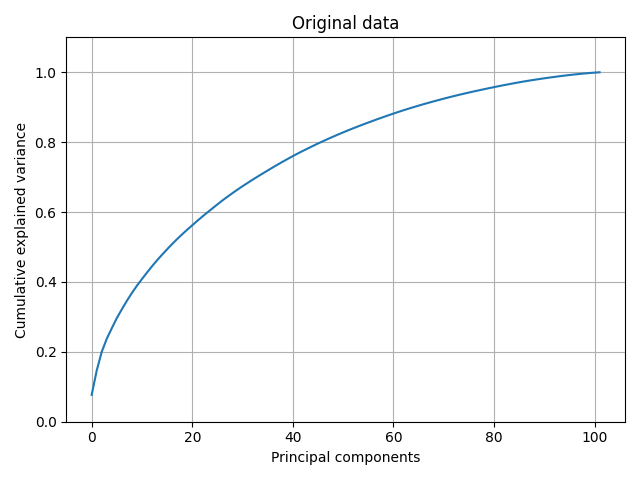

In [58]:
plot_cumulative_explained_variance(pca_xdf, title='Original data')

Cumulative explained variance for PC1:	0.0703
Cumulative explained variance for PC20:	0.5148
Cumulative explained variance for PC40:	0.7228


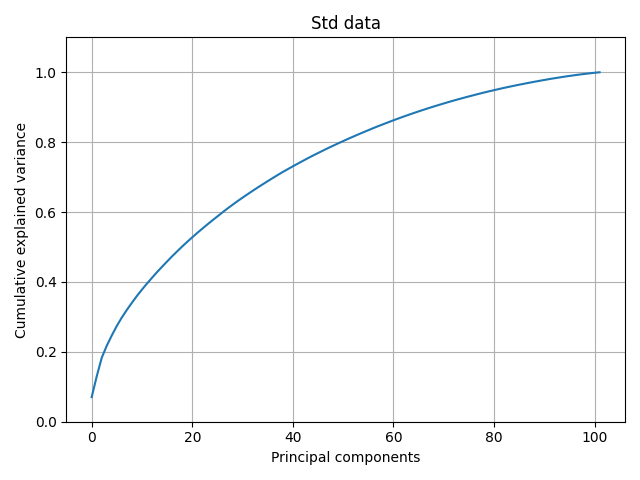

In [59]:
plot_cumulative_explained_variance(pca_std, title='Std data')

Cumulative explained variance for PC1:	0.0748
Cumulative explained variance for PC20:	0.5428
Cumulative explained variance for PC40:	0.7453


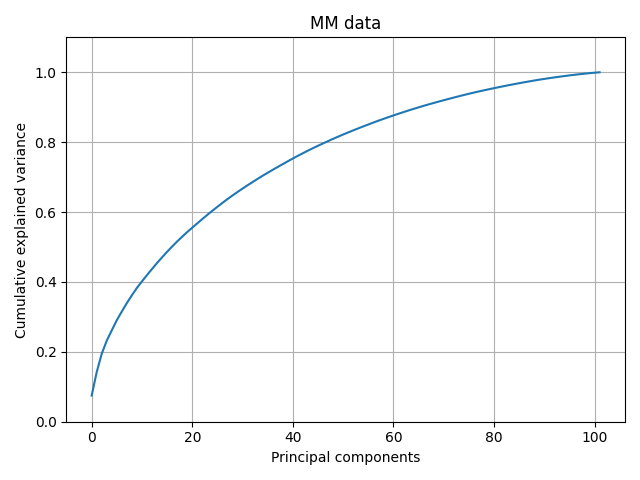

In [60]:
plot_cumulative_explained_variance(pca_mm, title='MM data')

Plotting the explained variance by principal components we note negligible differences among scaled and raw data. Neverthless we still proceeded to pick some arbitrary principal components to analytically verifiy if nature of eventual differences, if existing

| Data Type           | PC1 (Cumulative Explained Variance) | PC20 (Cumulative Explained Variance) | PC40 (Cumulative Explained Variance) |
|---------------------|-------------------------------------|--------------------------------------|--------------------------------------|
| **Raw**             | 0.0769                              | 0.5495                               | 0.7523                               |
| **Std Data**        | 0.0703                              | 0.5148                               | 0.7228                               |
| **MM Data**         | 0.0748                              | 0.5428                               | 0.7453                               |

We notice that PCs of the Standard scaled data tend to have a less significant explained variance among all three arbitrary PCs used in our analysis. Despite these differences (still considered irrelevant to our analysis, since they rely on the order of $10^{-2}$) we have a pretty similar cumulative distribution between raw and scaled PCs, such similarity must be ascribed to raw data features being already coherent by means of range in which values can span (i.e. `[1, ..., 5]`) (MMs) and distributed normally (STDs), at least in the most majority of cases, which causes the scalers to not sort notable effects.  


## Exercise 3. Dimensionality Reduction and PC Interpretation

In the cells below, do the following operations:
1. For each one of the two dataframes _Xstd_df_, and _Xmm_df_, compute a new PCA for performing a dimensionality reduction with respect to $m$ dimensions. The value of $m$ must be $$m = \min\{m', 5\}\,,$$ where $m'$ is the value required for obtaining $33\%$ of the total variance.
2. For both the cases, visualize all the PCs and give a name/interpretation to them. **Comment and motivate your interpretations**. If possible, **compare the differences among the results obtained** for _Xstd_df_ and _Xmm_df_.
3. Perform the score graph for both the cases (_std_ and _mm_). If $m>3$, plot the score graph with respect to the first 3 PCs. All the **plots must show the names of the PCs on the axes** for better understanding the results.
4. **Optional:** plot more score graphs, coloring the dots with respect to any label in the list _labels_ that you believe can be interesting. **Comment and analyze this optional plots**.

In [61]:
# Color coding for feature's contribution to PCs

features_in_X = set(X_df.columns)
columns_df = pd.read_csv('columns_hw.csv')
columns_df = columns_df[columns_df['short'].isin(features_in_X)]
categories = list(variables_by_type.keys())
n_colors = len(categories)
colors = cm.Set1(np.linspace(0, 1, n_colors))
category_colors = dict(zip(categories, colors))

feature_to_category = {}
for category, features in variables_by_type.items():
    for feature in features:
        feature_to_category[feature] = category
        
categories_in_data = list(set([feature_to_category[col] for col in X_df.columns]))
category_colors_filtered = {category: category_colors[category] for category in categories_in_data}
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, color=category_colors_filtered[category], label=category)
    for category in categories_in_data
]
colors_type = [category_colors[feature_to_category[col]] for col in X_df.columns]

In [62]:
# Principal components names
pc_names_std= [
    "Interest in Liberal Arts",
    "(-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)",
    "Social life and interest in Sports & Music",
    "(-) Having Unhealthy Habits vs. Interest in Life Sciences (+)",
    "Nerdiness"
]
pc_names_mm= [
    "Interest in Liberal Arts",
    "(-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)",
    "Interest in Sports & Music",
    "(-) Having Unhealthy Habits vs. Interest in Life Sciences (+)",
    "Geekness"
]

In [63]:
# Compute the effective PCA of the dataset

def find_n_components(explained_variance_ratio, target_variance=0.33):
    cumsum = np.cumsum(explained_variance_ratio)
    n_components = np.argmax(cumsum >= target_variance) + 1
    return min(n_components, 5)

m_std = find_n_components(pca_std.explained_variance_ratio_)
m_mm = find_n_components(pca_mm.explained_variance_ratio_)

pca_std_m= PCA(n_components= m_std)
pca_mm_m= PCA(n_components= m_mm)

pca_std_m.fit(Xstd_df)
pca_mm_m.fit(Xmm_df)

Ystd = pca_std_m.transform(Xstd_df)
Ymm = pca_mm_m.transform(Xmm_df)

We tried different heuristics to cap the number of componets to be considered singnificant, given that the classical one used during the course was not so discriminative in this case, we choose a simple heuristic such that:
$$S_j=\{ i : |x_{ij}|>=\epsilon_j\}  $$
$$\epsilon_j = 0.7*max(abs(x_{ij}))$$

Where
- $S_j$ denote the set of significant features for the principal component $j$;
- $x_{ij}$ denote the loading of the original feature $i$ with respect to the principal component $j$;
- $\epsilon_j$ denote the thereshold for the principal component $j$.
  
We assigned names to principal components considering original features belonging to sets obtained from the heuristic described above. In particular:

- we observed that the first two principal components, togheter with the 4th, derived from _Xmm_df_, are a bit more discriminative (by means of number of significant features resulted using our euristic) than those ones performed with _Xstd_df_;

- considering the 3rd principal component, the one obtained from _Xstd_df_ is characterized from features belonging to *Personality* and *Interests* categories, while the _Xmm_df_'s one higly depends only from the *Interest*'s features;

- concerning the 5th principal components, the features belonging to _Xstd_df_ describe perfectly the stereotype of *nerdiness*, while the _Xmm_df_'s one contained one features realted to *Phobias* (`Spiders`) and two related to STEM topics (`Mathematics` and `Physics`) instead of `Loneliness` and `Internet`

Despite these minor details, on the whole all PCs appeared pretty similar, therefore we adopted same namings.

In [64]:
def bar_plot_PC(m, pca, eps_euristic_rate, scaler_used, pc_names, figsize=None):
    for ii in range(m):

        # Define the threshold using our heuristic
        eps = eps_euristic_rate * np.max(np.abs(pca.components_[ii, :]))
        
        # Plot loadings and the threshold as a straight line
        plt.figure(figsize)
        plt.bar(np.arange(pca.n_features_in_),
               pca.components_[ii,:],
               color = colors_type)
        plt.plot([-0.5, pca.n_features_in_ - 0.5], [eps, eps], 'red')
        plt.plot([-0.5, pca.n_features_in_ - 0.5], [-eps, -eps], 'red')
        plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xlabel("Original features")
        plt.ylabel("Component contribution w.r.t. PC")
        plt.grid()
        plt.title( f'PC{ii+1} {scaler_used}: {pc_names[ii]}')
        plt.tight_layout()
        plt.show()
        
        # Selection of features which contributed signficantly to the PC
        ind_great_pos_PCii = np.argwhere(pca.components_[ii, :] >= eps).flatten()
        ind_great_neg_PCii = np.argwhere(pca.components_[ii, :] <= -eps).flatten()
        
        great_pos_PCii = [X_df.columns[i] for i in ind_great_pos_PCii]
        great_neg_PCii = [X_df.columns[i] for i in ind_great_neg_PCii]

        # Format the lists with each element on a new line
        formatted_pos_components = '\n'.join([f'│ ➕ {item}' for item in great_pos_PCii])
        formatted_neg_components = '\n'.join([f'│ ➖ {item}' for item in great_neg_PCii])
        
        # Print the analysis with formatted components and subtitles
        print(f'┌{"─" * 64}┐')
        print(f'│ 📊 PC{ii+1} {scaler_used} Analysis\t\t\t\t\t\t │')
        print(f'│ Name: {pc_names[ii]}\t\t\t\t │')
        print(f'├{"─" * 64}┤')
        
        # High-Valued Positive Components Section
        print(f'│ 🟢 HIGH-VALUED POSITIVE COMPONENTS\t\t\t\t │')
        print(f'├{"─" * 64}┤')
        print(f'{formatted_pos_components}')
        print(f'├{"─" * 64}┤')
        
        # High-Valued Negative Components Section
        print(f'│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS\t\t\t\t │')
        print(f'├{"─" * 64}┤')
        print(f'{formatted_neg_components}')
        print(f'└{"─" * 64}┘')

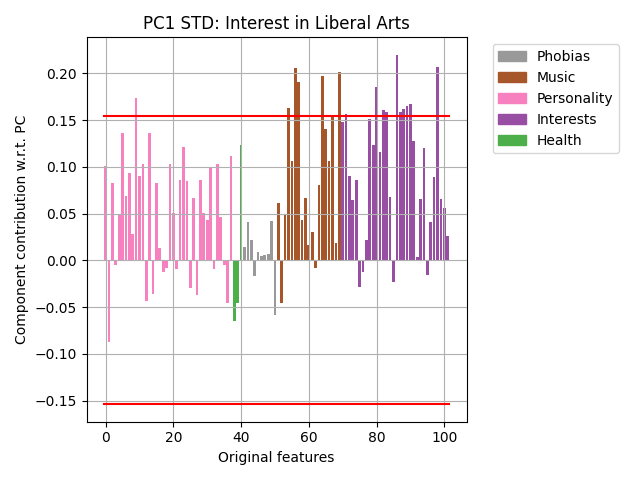

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC1 STD Analysis						 │
│ Name: Interest in Liberal Arts				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Workaholism
│ ➕ Folk
│ ➕ Classical music
│ ➕ Musical
│ ➕ Swing, Jazz
│ ➕ Latino
│ ➕ Opera
│ ➕ Psychology
│ ➕ Reading
│ ➕ Foreign languages
│ ➕ Medicine
│ ➕ Art exhibitions
│ ➕ Religion
│ ➕ Countryside, outdoors
│ ➕ Dancing
│ ➕ Musical instruments
│ ➕ Theatre
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


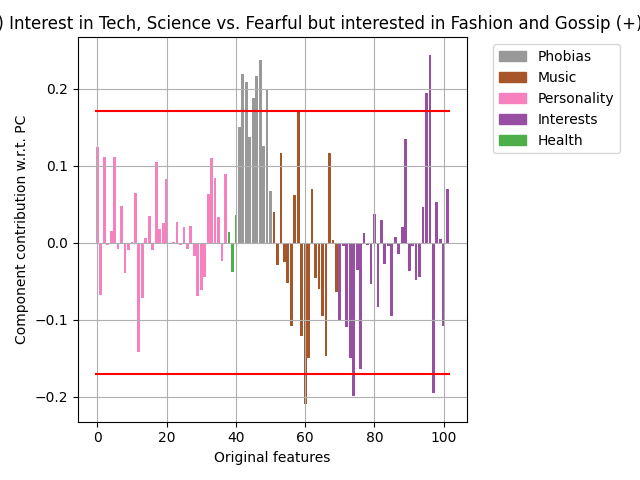

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC2 STD Analysis						 │
│ Name: (-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Storm
│ ➕ Darkness
│ ➕ Spiders
│ ➕ Snakes
│ ➕ Rats
│ ➕ Dangerous dogs
│ ➕ Celebrities
│ ➕ Shopping
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➖ Metal or Hardrock
│ ➖ Physics
│ ➖ Science and technology
└────────────────────────────────────────────────────────────────┘


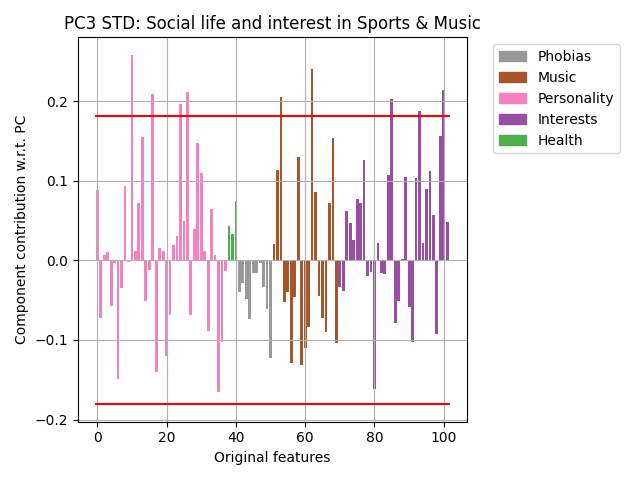

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC3 STD Analysis						 │
│ Name: Social life and interest in Sports & Music				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Energy levels
│ ➕ Personality
│ ➕ Socializing
│ ➕ Happiness in life
│ ➕ Dance
│ ➕ Hiphop, Rap
│ ➕ Cars
│ ➕ Active sport
│ ➕ Adrenaline sports
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


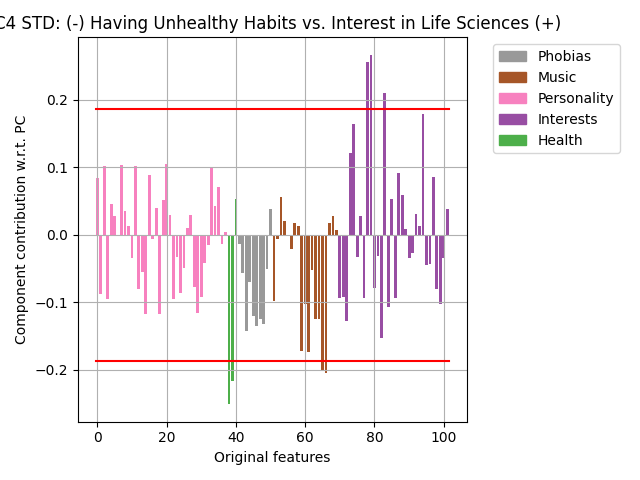

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC4 STD Analysis						 │
│ Name: (-) Having Unhealthy Habits vs. Interest in Life Sciences (+)				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Biology
│ ➕ Chemistry
│ ➕ Medicine
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➖ Smoking
│ ➖ Alcohol
│ ➖ Rock n roll
│ ➖ Alternative
└────────────────────────────────────────────────────────────────┘


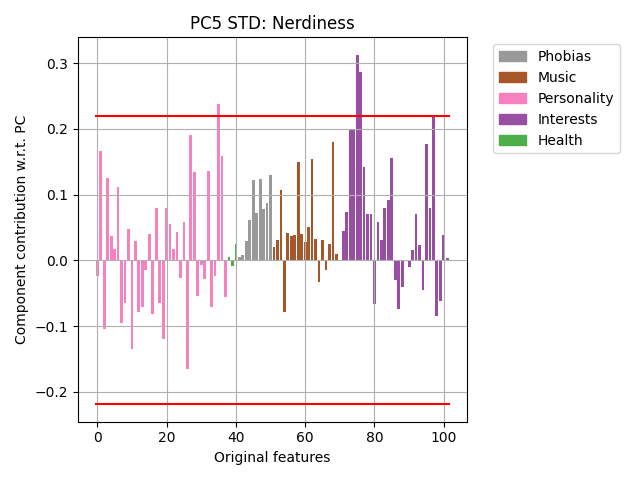

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC5 STD Analysis						 │
│ Name: Nerdiness				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Loneliness
│ ➕ Internet
│ ➕ PC
│ ➕ Science and technology
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


In [65]:
bar_plot_PC(m_std, pca_std, 0.7, "STD", pc_names_std)

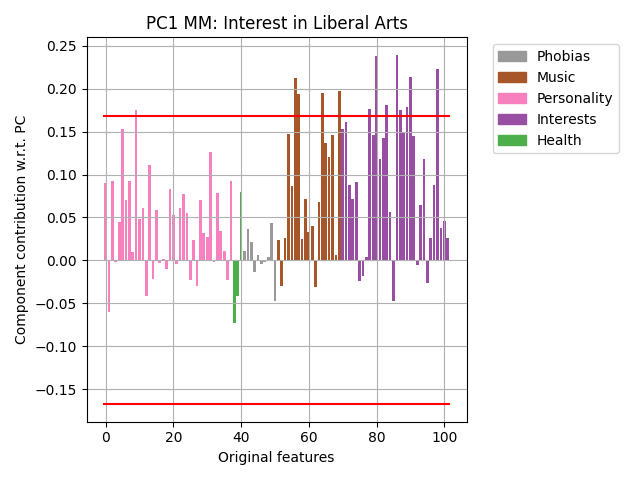

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC1 MM Analysis						 │
│ Name: Interest in Liberal Arts				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Workaholism
│ ➕ Classical music
│ ➕ Musical
│ ➕ Swing, Jazz
│ ➕ Opera
│ ➕ Biology
│ ➕ Reading
│ ➕ Medicine
│ ➕ Art exhibitions
│ ➕ Religion
│ ➕ Dancing
│ ➕ Musical instruments
│ ➕ Theatre
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


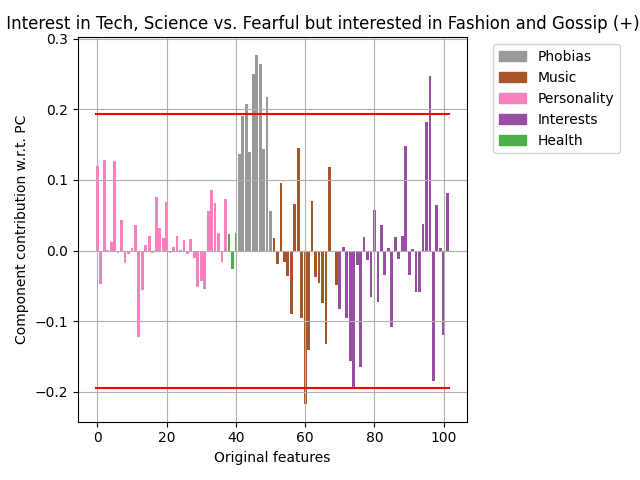

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC2 MM Analysis						 │
│ Name: (-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Darkness
│ ➕ Spiders
│ ➕ Snakes
│ ➕ Rats
│ ➕ Dangerous dogs
│ ➕ Shopping
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➖ Metal or Hardrock
│ ➖ Physics
└────────────────────────────────────────────────────────────────┘


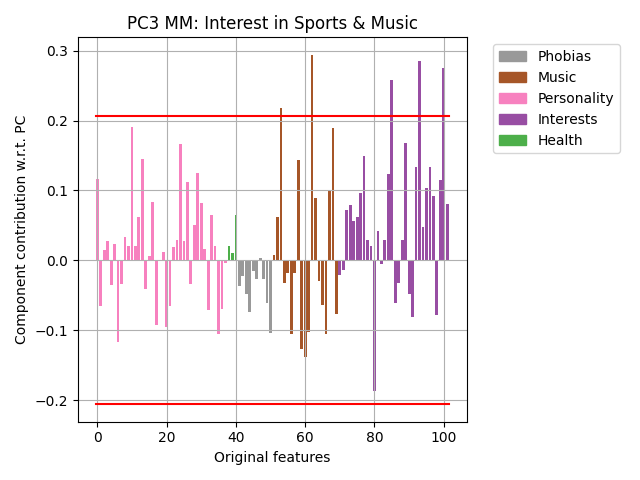

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC3 MM Analysis						 │
│ Name: Interest in Sports & Music				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Dance
│ ➕ Hiphop, Rap
│ ➕ Cars
│ ➕ Active sport
│ ➕ Adrenaline sports
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


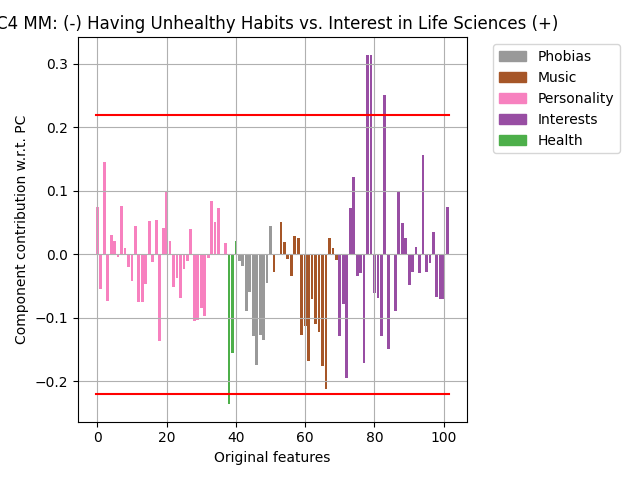

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC4 MM Analysis						 │
│ Name: (-) Having Unhealthy Habits vs. Interest in Life Sciences (+)				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Biology
│ ➕ Chemistry
│ ➕ Medicine
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➖ Smoking
└────────────────────────────────────────────────────────────────┘


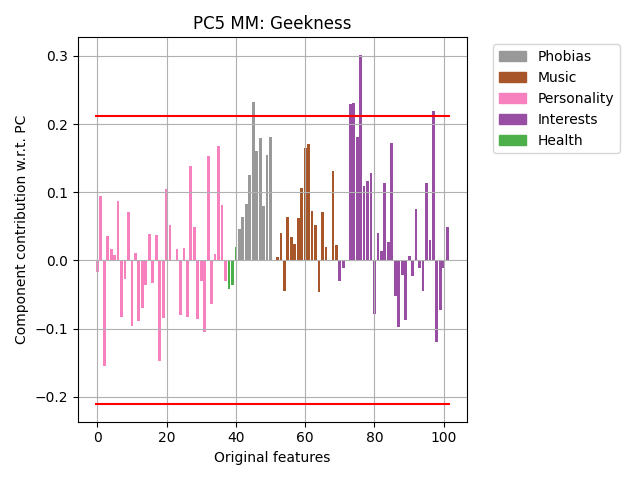

┌────────────────────────────────────────────────────────────────┐
│ 📊 PC5 MM Analysis						 │
│ Name: Geekness				 │
├────────────────────────────────────────────────────────────────┤
│ 🟢 HIGH-VALUED POSITIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤
│ ➕ Spiders
│ ➕ Mathematics
│ ➕ Physics
│ ➕ PC
│ ➕ Science and technology
├────────────────────────────────────────────────────────────────┤
│ 🔴 HIGH-VALUED NEGATIVE COMPONENTS				 │
├────────────────────────────────────────────────────────────────┤

└────────────────────────────────────────────────────────────────┘


In [66]:
bar_plot_PC(m_mm, pca_mm, 0.7, "MM", pc_names_mm)

We now proceed to build dataframes using these new PC and their namings for better interpretability of data

In [67]:
Ystd_df = pd.DataFrame(Ystd, columns=pc_names_std)

In [68]:
Ystd_df

,Interest in Liberal Arts,"(-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)",Social life and interest in Sports & Music,(-) Having Unhealthy Habits vs. Interest in Life Sciences (+),Nerdiness
0,-0.079278,-2.484704,-0.519389,-3.130481,0.378227
1,2.720328,0.200188,1.659324,-3.232451,0.057228
2,-1.141342,-0.384703,1.344862,3.160627,2.843385
3,-2.749501,-3.646601,2.275109,-1.935626,-3.142187
4,-0.457672,-3.473858,-0.750864,-1.780734,-0.506721
...,...,...,...,...,...
479,0.837347,-1.945136,-4.462289,0.923754,-2.398992
480,-2.024262,-0.823004,0.147564,-0.698924,-0.173525
481,-4.408951,-1.310650,-2.505277,-3.606685,-1.795206
482,2.220508,-6.276852,2.237916,-0.057586,-0.379222


In [69]:
Ymm_df = pd.DataFrame(Ymm, columns=pc_names_mm)

In [70]:
Ymm_df

,Interest in Liberal Arts,"(-) Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip (+)",Interest in Sports & Music,(-) Having Unhealthy Habits vs. Interest in Life Sciences (+),Geekness
0,0.041684,-0.609603,-0.496492,-1.146534,-0.272394
1,0.648464,0.120992,0.523449,-1.155732,-0.275934
2,-0.448692,-0.130644,0.527352,0.747433,1.098222
3,-0.953023,-1.132367,0.087415,-0.465187,-0.942690
4,-0.079450,-1.132818,-0.566644,-0.284635,0.397477
...,...,...,...,...,...
479,0.437190,-0.630515,-1.386639,0.303947,-0.250785
480,-0.662870,-0.074377,0.002940,-0.545151,-0.174996
481,-1.192128,-0.278270,-0.972210,-0.887362,-0.508679
482,0.702790,-1.938958,0.570551,-0.151217,-0.195665


In [71]:
X_df_labels

,Age,Height,Weight,Number of siblings,Gender,Hand,Education,Only child,Home Town Type,Home Type
0,19.0,193.0,77.0,1.0,male,right,secondary school,yes,city,block of flats
1,18.0,161.0,74.0,1.0,female,right,primary school,no,city,block of flats
2,19.0,185.0,78.0,2.0,male,left,secondary school,no,village,house/bungalow
3,19.0,184.0,60.0,4.0,male,right,college/bachelor degree,no,city,block of flats
4,21.0,183.0,73.0,0.0,female,right,secondary school,yes,city,block of flats
...,...,...,...,...,...,...,...,...,...,...
479,26.0,169.0,70.0,2.0,male,right,masters degree,no,city,house/bungalow
480,20.0,187.0,95.0,0.0,male,right,secondary school,yes,city,block of flats
481,21.0,165.0,55.0,1.0,female,right,secondary school,yes,city,block of flats
482,20.0,188.0,80.0,3.0,male,right,college/bachelor degree,no,city,block of flats


In [72]:
Ystd_df_with_labels = pd.concat([Ystd_df, X_df_labels], axis=1)
#Ystd_df_with_labels

In [73]:
Ymm_df_with_labels = pd.concat([Ymm_df, X_df_labels], axis=1)
#Ymm_df_with_labels

Once such dataframes are defined, we can proceed to plot score graphs according to labels, eventually following a color coding for better visualization

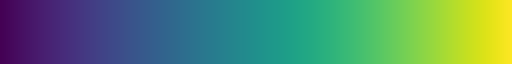

In [74]:
plt.colormaps.get_cmap('viridis')

In [75]:
def scatter_2d_plot(
    data, 
    axis_names=["Axis 1", "Axis 2"], 
    color=None, 
    color_labels=None, 
    cluster_centers=None, 
    cluster_names=None, 
    scatter_alpha=1, 
    title=None, 
    figsize=None, 
):
    # If a DataFrame is passed, convert it to a numpy matrix
    if isinstance(data, pd.DataFrame):
        data = data.values

    # Use the first 2 columns as axes
    x_axis, y_axis = data[:, 0], data[:, 1]

    # Create the plot
    plt.figure(figsize=figsize)
    plt.scatter(x_axis, y_axis, c=color, alpha=scatter_alpha)

    # Add legend if color_labels is provided
    if color_labels:
        handles = [plt.Line2D([0], [0], marker='o', color=clr, markersize=10, linestyle='') for clr in color_labels.keys()]
        plt.legend(handles, color_labels.values(), title="Legend")

    # Plot cluster centers if provided
    if cluster_centers is not None:
        k = cluster_centers.shape[0]  # Number of clusters

        if cluster_names is None:
            cluster_names = [f"Cluster {i+1}" for i in range(k)]

        for kk in range(k):
            plt.scatter(
                cluster_centers[kk, 0],  # x-coordinate
                cluster_centers[kk, 1],  # y-coordinate
                s=200, color='red', marker='X', label=f'Centroid {kk+1}'  # Customize appearance
            )
            plt.text(
                cluster_centers[kk, 0], 
                cluster_centers[kk, 1], 
                cluster_names[kk],
                fontsize=11, 
                color='black', 
                weight='bold'
            )

    # Set axis labels
    plt.xlabel(axis_names[0])
    plt.ylabel(axis_names[1])

    # Add title
    if not title:
        title = '2D Scatter Plot'
    plt.title(title)

    # Show grid and plot
    plt.grid()
    plt.show()

In [76]:
def scatter_3d_plot(
    data, 
    axis_names=["Axis 1", "Axis 2", "Axis 3"], 
    color=None, 
    color_labels=None, 
    cluster_centers=None, 
    cluster_names=None, 
    scatter_alpha=1, 
    title=None, 
    figsize=None
):
    # If a DataFrame is passed, convert it to a numpy matrix
    if isinstance(data, pd.DataFrame):
        data = data.values
    
    # Use the first 3 columns as axes
    x_axis, y_axis, z_axis = data[:, 0], data[:, 1], data[:, 2]
    
    # Plot data
    sg_3d = plt.figure(figsize)
    ax_sg_3d = sg_3d.add_subplot(111, projection='3d')
    
    # Scatter plot for data points
    ax_sg_3d.scatter(x_axis, y_axis, z_axis, color=color, alpha=scatter_alpha)

    # Add legend if color_labels is provided
    if color_labels:
        handles = [plt.Line2D([0], [0], marker='o', color=clr, markersize=10, linestyle='') for clr in color_labels.keys()]
        plt.legend(handles, color_labels.values(), title="Legend")

    # Plot cluster centers if provided
    if cluster_centers is not None:
        k = cluster_centers.shape[0]  # Number of clusters

        if cluster_names is None:
            cluster_names = [f"Cluster {i+1}" for i in range(k)]

        for kk in range(k):
            ax_sg_3d.text(
                cluster_centers[kk, 0],  # x-coordinate
                cluster_centers[kk, 1],  # y-coordinate
                cluster_centers[kk, 2],  # z-coordinate
                cluster_names[kk],
                fontsize=11, 
                color='black', 
                weight='bold'
            )
            ax_sg_3d.scatter(
                cluster_centers[kk, 0],  # x-coordinate
                cluster_centers[kk, 1],  # y-coordinate
                cluster_centers[kk, 2],  # z-coordinate
                s=200, color='red', marker='X', label=f'Centroid {kk+1}'  # Customize appearance
            )
    
    # Set axis labels
    ax_sg_3d.set_xlabel(axis_names[0])
    ax_sg_3d.set_ylabel(axis_names[1])
    ax_sg_3d.set_zlabel(axis_names[2])

    # Add title
    if not title:
        title = 'SURVEY - SCORE GRAPH'
    plt.title(title)
    
    # Show grid and plot
    plt.grid()
    plt.show()


In [77]:
def scatter_plot(
    df, 
    axis_names, 
    label='Age', 
    cmap='viridis', 
    km=None, 
    cluster_names=None, 
    scatter_alpha=1, 
    title=None, 
    figsize=None
):
    
    # Default color column is 'Age', but can be overridden
    if label not in df.columns:
        raise ValueError(f"The specified color column '{label}' is not in the DataFrame.")

    # Use the chosen colormap
    colormap = plt.colormaps.get_cmap(cmap)
    
    # Check if the column is categorical or numerical
    if df[label].dtype in ['float', 'int']:
        # Handle numerical columns with MinMaxScaler
        colors = MinMaxScaler((0, 255)).fit_transform(df[label].values.reshape(-1, 1))
        colors = pd.Series(colors.flatten()).apply(int)
        colors = colors.apply(lambda x: colormap(x / 255))  # Normalize to [0, 1] for colormap
        color_labels = None
        
    else:
        # Handle categorical columns by mapping them to discrete colors
        color_map = dict()
        color_labels = dict()
        unique_values = df[label].unique()

        for i, value in enumerate(unique_values):
            color = colormap((i+1) / len(unique_values))
            color_map[value] = color
            color_labels[color] = value
        colors = df[label].map(color_map)

    # Default title
    if not title:
        title = f'SURVEY - SCORE GRAPH w\ COLOR-CODING ON {label}'

    # Extract data
    pca_data = df[axis_names].values

    # Extract cluster centers
    if km:
        cluster_centers_indices = [df.columns.get_loc(col) for col in axis_names]
        cluster_centers = km.cluster_centers_[:, cluster_centers_indices]
    else:
        cluster_centers = None

    # Call dedicated 3D scatter function defined above
    if pca_data.shape[1] > 2:
        scatter_3d_plot(pca_data, axis_names, color=colors, color_labels=color_labels, cluster_centers=cluster_centers, cluster_names=cluster_names, scatter_alpha=scatter_alpha, title=title, figsize=figsize)
    elif pca_data.shape[1] == 2:
        scatter_2d_plot(pca_data, axis_names, color=colors, color_labels=color_labels, cluster_centers=cluster_centers, cluster_names=cluster_names, scatter_alpha=scatter_alpha, title=title, figsize=figsize)
    else:
        raise ValueError("Can't plot less than 2 dimensions.")

By plotting the distributions with respect to the first three principal components, we noticed that the only demographic label showing an interesting pattern is the `Gender` label.

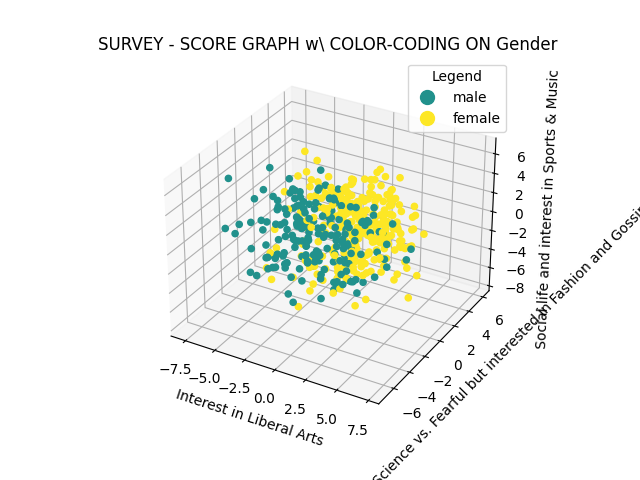

In [78]:
scatter_plot(Ystd_df_with_labels, axis_names=pc_names_std, label='Gender', cmap='viridis')

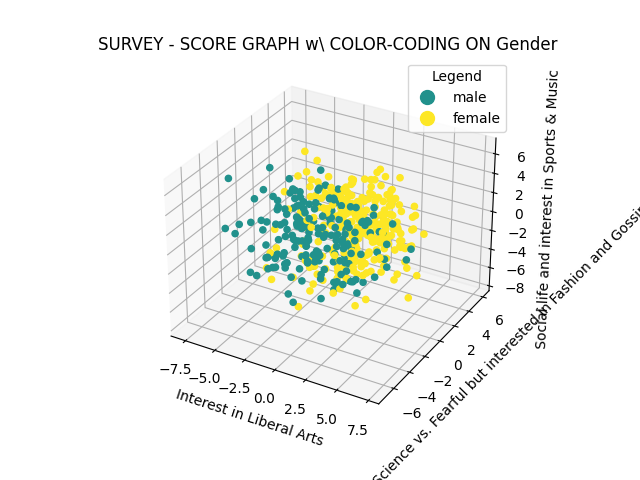

In [79]:
scatter_plot(Ystd_df_with_labels, axis_names=pc_names_std, label='Gender', cmap='viridis')

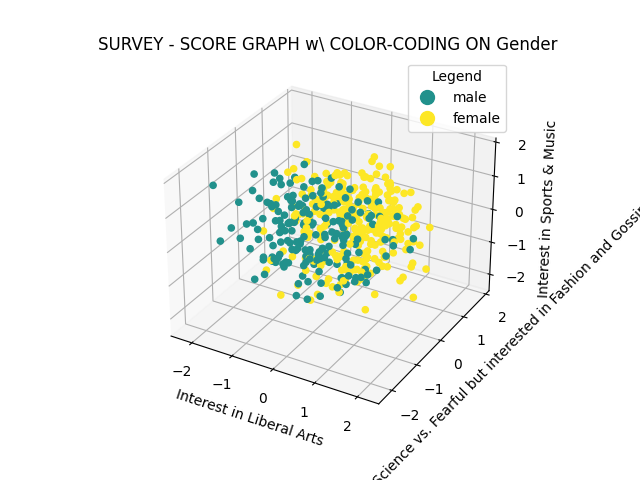

In [80]:
scatter_plot(Ymm_df_with_labels, axis_names=pc_names_mm, label='Gender', cmap='viridis')

In [81]:
def plot_all_pca_combinations(df, pc_names_std, label='Gender', cmap='viridis', km=None, cluster_names=None, scatter_alpha=1, figsize=None):

    n_components = len(pc_names_std)
    
    for i in range(n_components):
        for j in range(i + 1, n_components):
            for k in range(j + 1, n_components):
                perm = [pc_names_std[i], pc_names_std[j], pc_names_std[k]]
                scatter_plot(df, axis_names=perm, label=label, cmap=cmap, km=km, cluster_names=cluster_names, scatter_alpha=scatter_alpha, title=f'PCA Combination: {perm}', figsize=figsize)

In [82]:
#plot_all_pca_combinations(Ystd_df_with_labels, pc_names_std, label='Gender', cmap='viridis') # To plot all possible combinations of the PCs in the color-coded score graph, uncomment to use!

To gain meaningful insights, we rotated the graph to visualize the distribution in two dimensions per time. We can observe the distribution of the classes of this label is clearly distinguishable if we include `Interest in Tech, Science vs. Fearful but interested in Fashion and Gossip` (*second component*) among the axes under analysis. While a combination of the other two `('Interest in Liberal Arts', 'Social life and interest in Sports & Music')` becomes less meaningful.

For *X_std* we obtain:

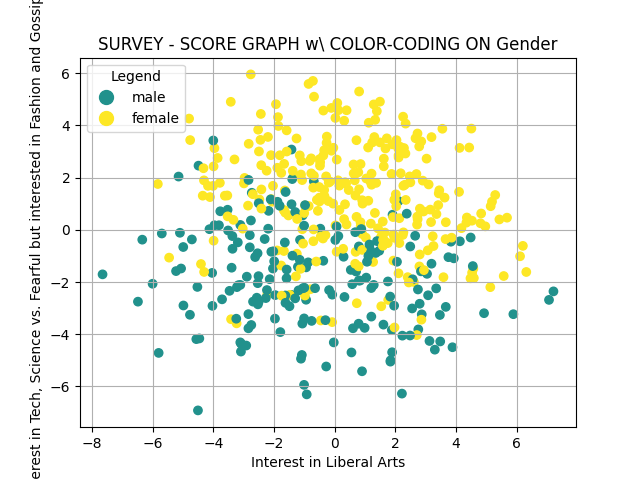

In [83]:
scatter_plot(
    Ystd_df_with_labels, 
    axis_names=[
        pc_names_std[0],
        pc_names_std[1]
    ],
    label='Gender',
    cmap='viridis'
)

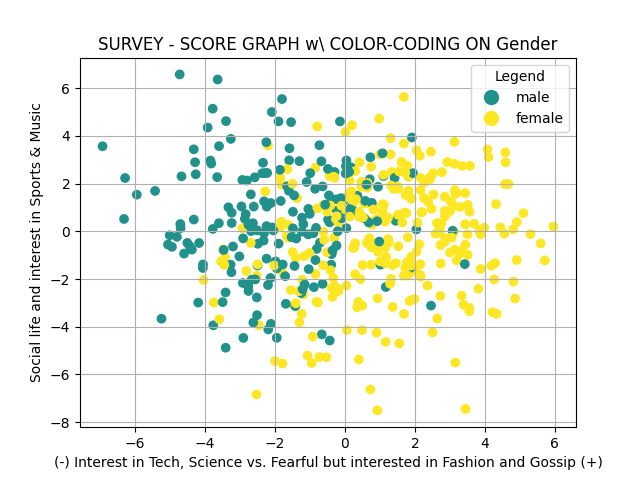

In [84]:
scatter_plot(
    Ystd_df_with_labels, 
    axis_names=[
        pc_names_std[1],
        pc_names_std[2]
    ],
    label='Gender',
    cmap='viridis'
)

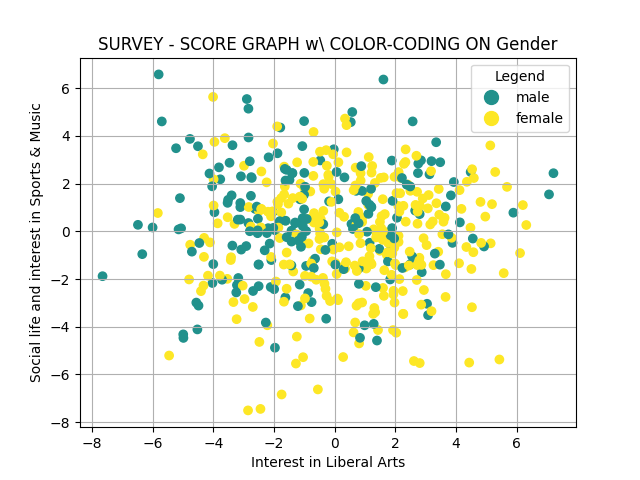

In [85]:
scatter_plot(
    Ystd_df_with_labels, 
    axis_names=[
        pc_names_std[0],
        pc_names_std[2]
    ],
    label='Gender',
    cmap='viridis'
)

For *X_mm* we obtain:

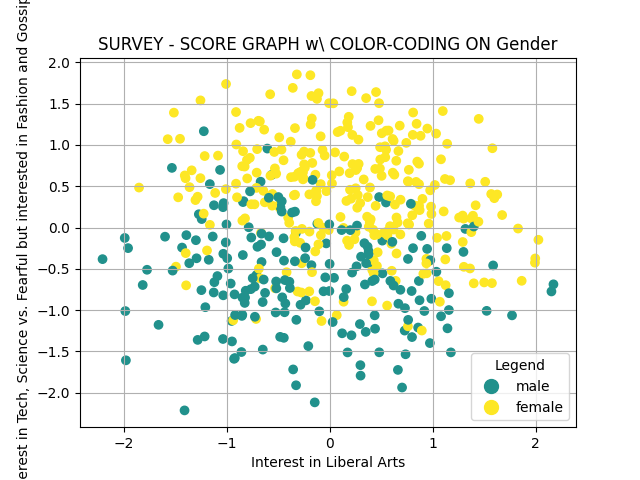

In [86]:
scatter_plot(
    Ymm_df_with_labels, 
    axis_names=[
        pc_names_mm[0],
        pc_names_mm[1]
    ],
    label='Gender',
    cmap='viridis'
)

C:\Users\carli\AppData\Local\Temp\ipykernel_16032\2386294445.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=figsize)


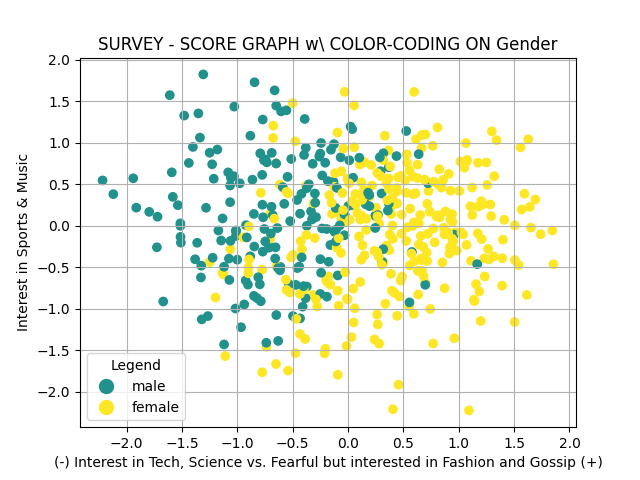

In [87]:
scatter_plot(
    Ymm_df_with_labels, 
    axis_names=[
        pc_names_mm[1],
        pc_names_mm[2]
    ],
    label='Gender',
    cmap='viridis'
)

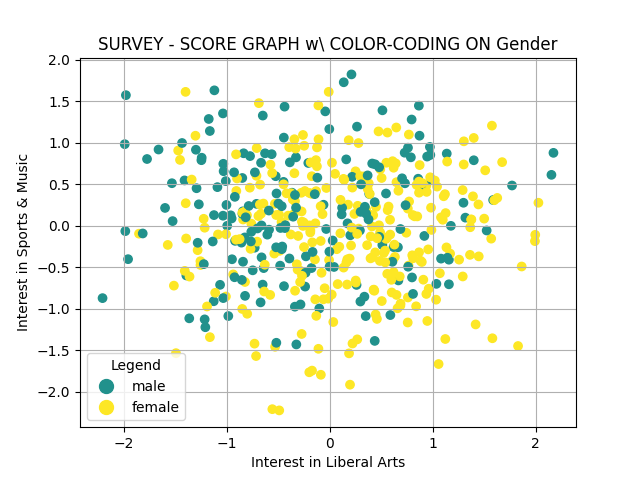

In [88]:
scatter_plot(
    Ymm_df_with_labels, 
    axis_names=[
        pc_names_mm[0],
        pc_names_mm[2]
    ],
    label='Gender',
    cmap='viridis'
)

## Exercise 4. $k$-Means

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), run the $k$-Means for clustering the data. In particular, **use the silohuette score for identify the best value for $k\in\{3, \ldots, 10\}$**.
2. Plot the score graphs of exercise 3.3, adding the centroids of the cluster.
3. Observing the centroids coordinates in the PC space, **give a name/interpretation to them**, exploiting the names you assigned to the PCs. **Comment and motivate your interpretations**.

In [89]:
clusters_names_std = [
    'Low Arts but Tech',
    'High Arts and Tech',
    'Fearful',
]
clusters_names_mm = [
    'Low Arts but Tech',
    'Fearful',
    'High Arts and Tech',
]

In [90]:
def evaluate_kmeans(Y, k_list = list(range(3, 11)), random_state=random_seed):

    km_list = []
    km_labels = []
    sil_coeff_list = []

    for k in k_list:

        # For better visualization
        print(f'┌{"─" * 64}┐')
        print(f'│ STARTING k-MEANS WITH k={k}\t\t\t\t\t │')
        print(f'├{"─" * 64}┤')
        print('│ Computing clustering...\t\t\t\t\t │')
        
        # Initialize and fit KMeans
        km = KMeans(n_clusters=k, random_state=random_state)
        labels = km.fit_predict(Y)
        
        # Append results
        km_list.append(km)
        km_labels.append(labels)
        sil_coeff = silhouette_score(Y, labels)
        sil_coeff_list.append(sil_coeff)
        
        print('│ Clustering complete!\t\t\t\t\t │')
        print(f'│ Found a cluster with {sil_coeff:.4f} average silhouette score\t │')
        print(f'└{"─" * 64}┘\n')

    # Find the best k and corresponding results
    best_idx = np.argmax(sil_coeff_list)
    k_best = k_list[best_idx]
    km_best = km_list[best_idx]
    labels_best = km_labels[best_idx]
    sil_coeff_best = sil_coeff_list[best_idx]

    # Visualize the result
    print('\n' + '━' * 64)
    print(f'BEST SILHOUETTE SCORE: {sil_coeff_best:.4f}  with  k = {k_best:<3}')
    print('━' * 64 + '\n')
    
    return k_best, km_best, labels_best, sil_coeff_best, silhouette_samples(Y, labels_best)

In [91]:
std_k_best, std_km_best, std_labels_best, std_sil_coeff_best, std_sil_samples = evaluate_kmeans(Ystd)

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=3					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1784 average silhouette score	 │
└────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=4					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1734 average silhouette score	 │
└────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=5					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1545 average silhouette sco

We observe that `kmeans` returns 3 clusters (i.e. `k=3` is the clustering with the highest number of silhouette score) distributed in the cloud of points. In particular this `k` value has a silhouette score which is significantly higer than the others: while `k=3` reports a silhouette score ~1.78, the other k choices reported values around ~1.55 mostly.

The distribution of clusters on the cloud may seem as lacking of meaning at a first glance, but in fact we can develop an interpretation for them if we move our view focusing on 2 PCs per time. If we anihilate the *interest in sport & music* dimension (*third principal component*), we notice a more meaningfull clustering between data. With 2 centroids placed on almost the same level of *bening fearful* againts the *interest in liberal arts* dimension.

We can infere that one centroid is dedicated to cluster all data points that have a significant high value in the *fearful* dimension, while the other two present a non-significant value in such dimension, but differenciate data based on the level of *interest in arts*.

Furthermore if we look at how the *gender* label is distributed we can infere that *females* tend to group around the *fearful people* centroid, while males evenly distribute themselves among the other two clusters, with a more mix of both genders around the *high interest in liberal arts* centroid. This interpretaion is coherent with what we discussed in Exercise (2) and (3), for which also the 3rd PC *interest in sports & music* resulted to be less meaningful to define the differences between the two genders. And for which females tended to be more interested in Liberal Arts, Fashion and having responded most times with a high score to phobias.

For *X_std* we obtain:

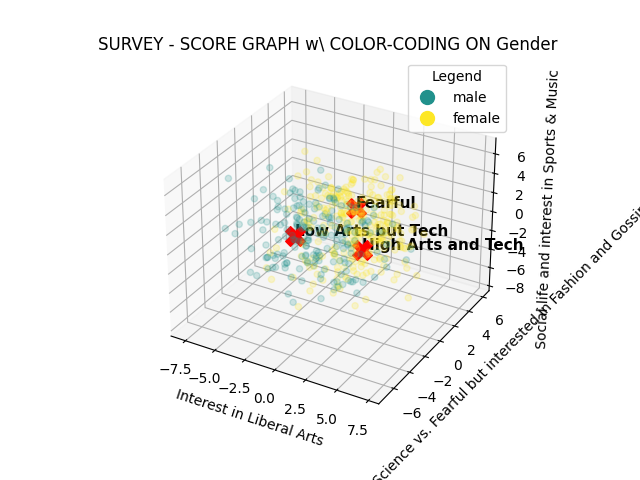

In [92]:
scatter_plot(Ystd_df_with_labels, axis_names=pc_names_std, label='Gender', cmap='viridis',  km=std_km_best, cluster_names=clusters_names_std, scatter_alpha=0.2)

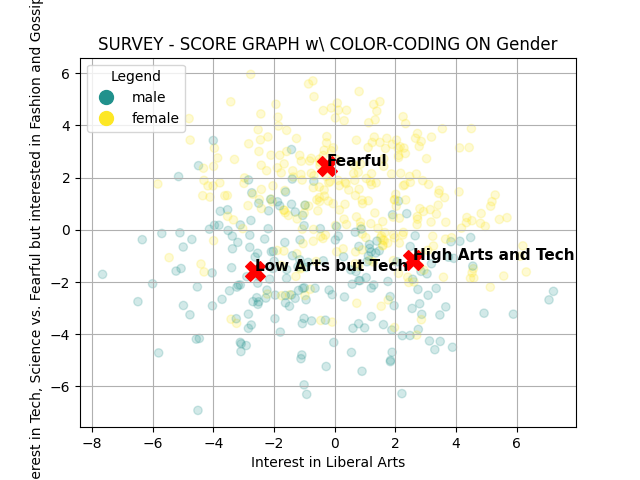

In [93]:
scatter_plot(Ystd_df_with_labels, axis_names=[pc_names_std[0], pc_names_std[1]], label='Gender', cmap='viridis',  km=std_km_best, cluster_names=clusters_names_std, scatter_alpha=0.2)

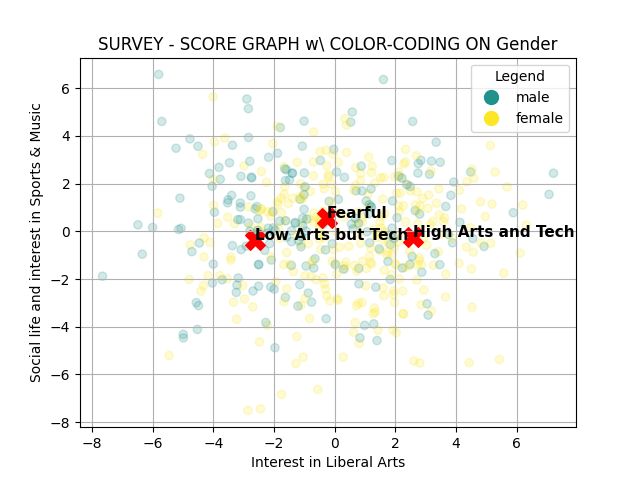

In [94]:
scatter_plot(Ystd_df_with_labels, axis_names=[pc_names_std[0], pc_names_std[2]], label='Gender', cmap='viridis',  km=std_km_best, cluster_names=clusters_names_std, scatter_alpha=0.2)

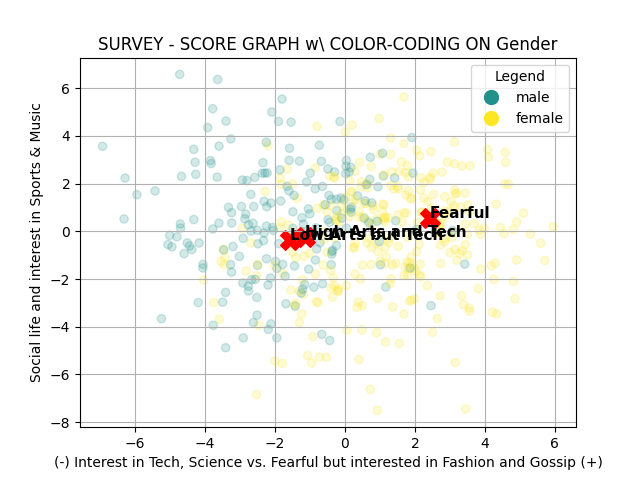

In [95]:
scatter_plot(Ystd_df_with_labels, axis_names=[pc_names_std[1], pc_names_std[2]], label='Gender', cmap='viridis',  km=std_km_best, cluster_names=clusters_names_std, scatter_alpha=0.2)

In [96]:
mm_k_best, mm_km_best, mm_labels_best, mm_sil_coeff_bes, mm_sil_samples = evaluate_kmeans(Ymm)

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=3					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1787 average silhouette score	 │
└────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=4					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1734 average silhouette score	 │
└────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────┐
│ STARTING k-MEANS WITH k=5					 │
├────────────────────────────────────────────────────────────────┤
│ Computing clustering...					 │
│ Clustering complete!					 │
│ Found a cluster with 0.1626 average silhouette sco

As discussed above, no significant differences are found between the min-max scaled data and the standardized one, therefore we expect that clustering in this data distribution will not have signficant differences compared to the previous. In fact this is also underlined by the magnitude of the silhouette scores reported, which are clearly similar to those of the clusters runned on standardized data.

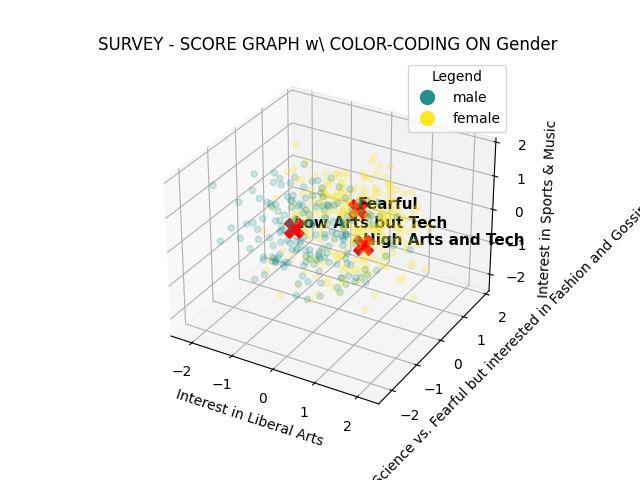

In [97]:
scatter_plot(Ymm_df_with_labels, axis_names=pc_names_mm, label='Gender', cmap='viridis',  km=mm_km_best, cluster_names=clusters_names_mm, scatter_alpha=0.2)

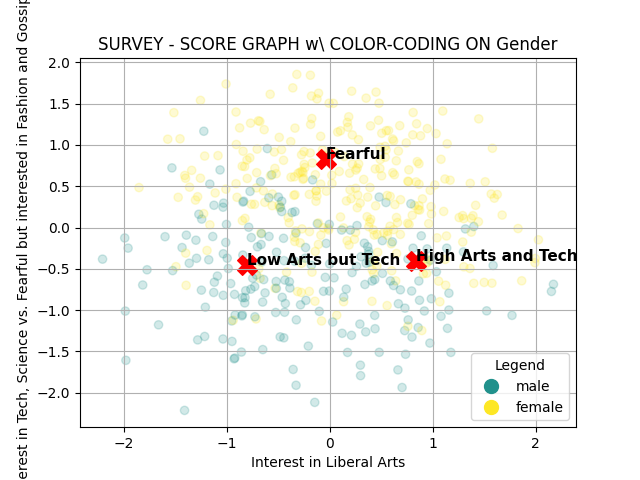

In [98]:
scatter_plot(Ymm_df_with_labels, axis_names=[pc_names_mm[0], pc_names_mm[1]], label='Gender', cmap='viridis',  km=mm_km_best, cluster_names=clusters_names_mm, scatter_alpha=0.2)

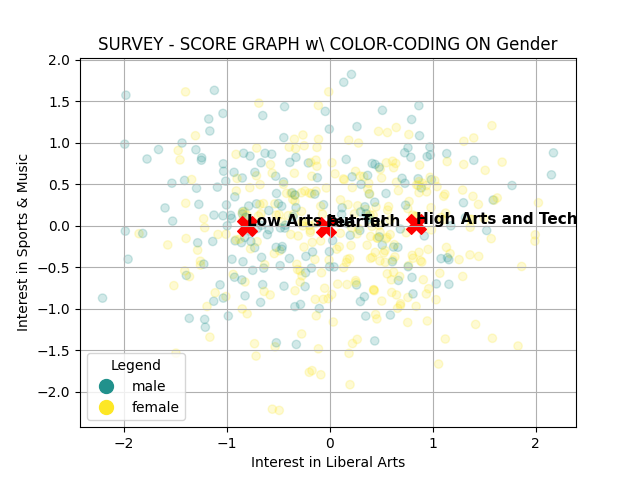

In [99]:
scatter_plot(Ymm_df_with_labels, axis_names=[pc_names_mm[0], pc_names_mm[2]], label='Gender', cmap='viridis',  km=mm_km_best, cluster_names=clusters_names_mm, scatter_alpha=0.2)

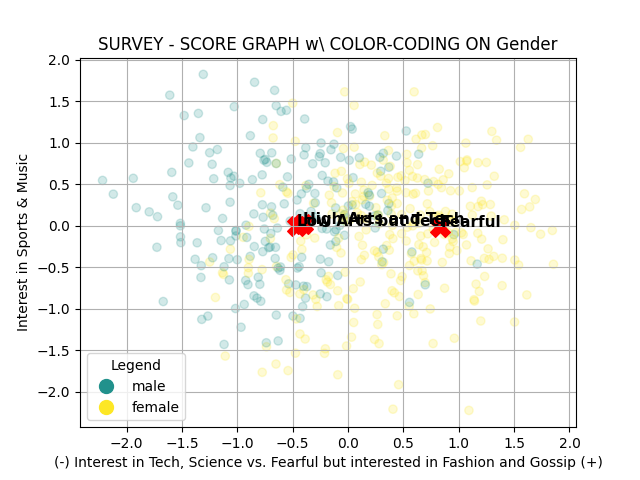

In [100]:
scatter_plot(Ymm_df_with_labels, axis_names=[pc_names_mm[1], pc_names_mm[2]], label='Gender', cmap='viridis',  km=mm_km_best, cluster_names=clusters_names_mm, scatter_alpha=0.2)

## Exercise 5. Cluster Evaluations

In the cells below, do the following operations:
1. For each one of the two datasets (_std_ and _mm_), perform an **external evaluation** of the clustering obtained at exercise 4.1 with respect to one or more labels in the list _labels_. **Comment the results, comparing the evaluation with the interpretation you gave at exercise 4.3**. 
2. For each one of the two datasets (_std_ and _mm_), perform an **internal evaluation** of each cluster, with respect to the silohuette score. **Comment the results**. 

In [101]:
def plot_kmeans_centroids(Y, km, pc_names, clusters_names, title="CENTROIDS BAR PLOT", figsize = (12, 8)):
    
    # Compute max/min values in PC-space
    maxs_y = Y.max(axis=0)
    mins_y = Y.min(axis=0)

    # Prepare the bar plots of the centroids
    num_clusters = km.n_clusters
    num_features = km.cluster_centers_.shape[1]

    # Plot
    fig, axes = plt.subplots(1, num_clusters, figsize=figsize)
    
    if num_clusters == 1:  # Handle case for a single cluster (k=1)
        axes = [axes]
    
    for ii in range(num_clusters):
        axes[ii].bar(np.arange(num_features), maxs_y, color='blue', alpha=0.15)
        axes[ii].bar(np.arange(num_features), mins_y, color='blue', alpha=0.15)
        axes[ii].bar(np.arange(num_features), km.cluster_centers_[ii, :], color='blue', alpha=0.35)
        axes[ii].set_xticks(np.arange(num_features))
        axes[ii].set_xticklabels(labels=pc_names, rotation=90)
        axes[ii].set_title(clusters_names[ii])
    
    # Add a title to the entire figure
    fig.suptitle(title, fontsize=16)  # Adjust `y` for spacing
    
    plt.tight_layout()
    plt.show()


We can observe the result of the kmeans algorithm by different means, in the following external evaluation we are able to appreciate the distribution of centroids among each dimension over the 3rd. Concerning the first 3 PCs already plotted we notice how this visualization is coherent with results found above, in particular the clusters for Low and High Interest in liberal arts are defined by a centroid placed on its coherent side of the component. Fearful people instead are mainly characterized by the second bar which is by far the most predominant among the other four. We also prove again what said in the previous interpretaion about component 3, which was not considered significant enough for how clusters where distributed. The main advantage of this visualization is that we can now extend the latter conclusion to the 4th and 5th components too, in particular we notice how *Nerdiness* is providing almost no information to characterize the clusters.

All these observations are consistent with our discussion of the explained variance among PCs. Beyond the second component, the variance contributing to cluster characterization becomes negligible.

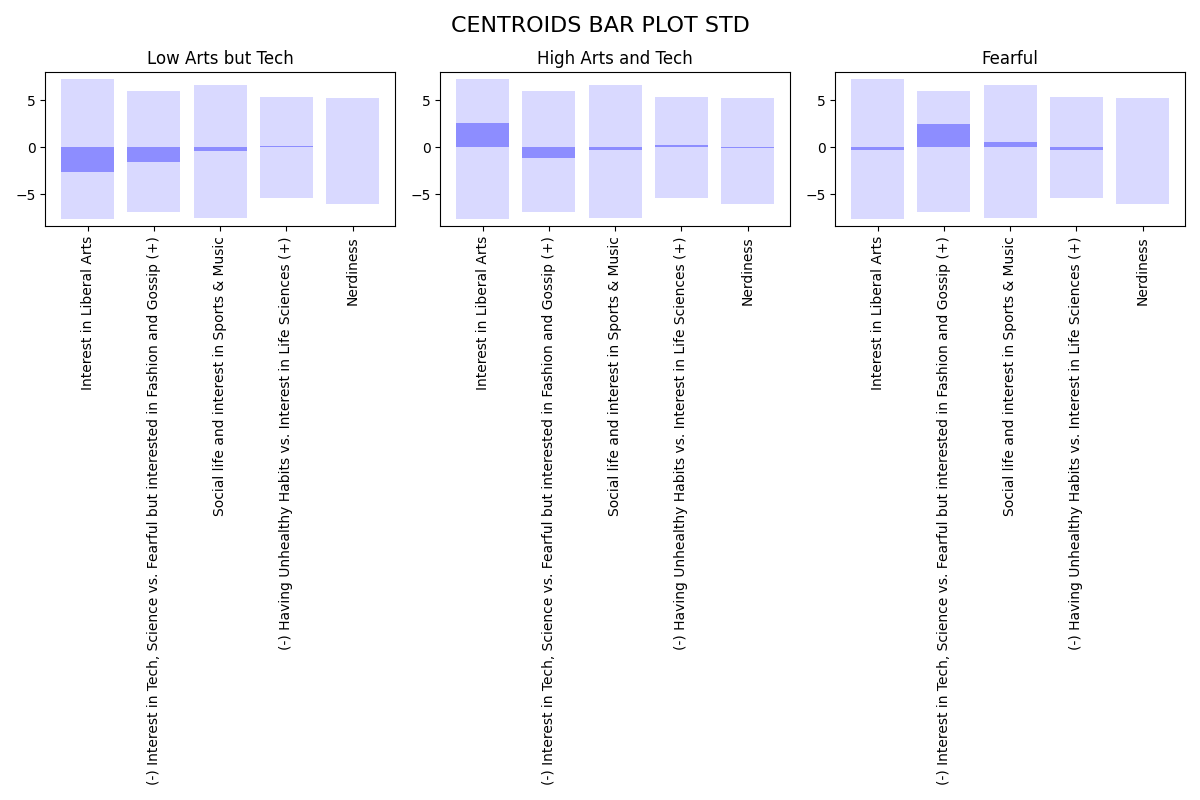

In [102]:
plot_kmeans_centroids(Ystd, std_km_best, pc_names_std, clusters_names_std, title="CENTROIDS BAR PLOT STD")

Exactly as before, the difference with the min-max scaled data is negligible. The only difference that can be appreciated is the one concerning all the components above the 2nd. For which the position of the centroid is now more centered among the cloud of points defined by their clusters.  

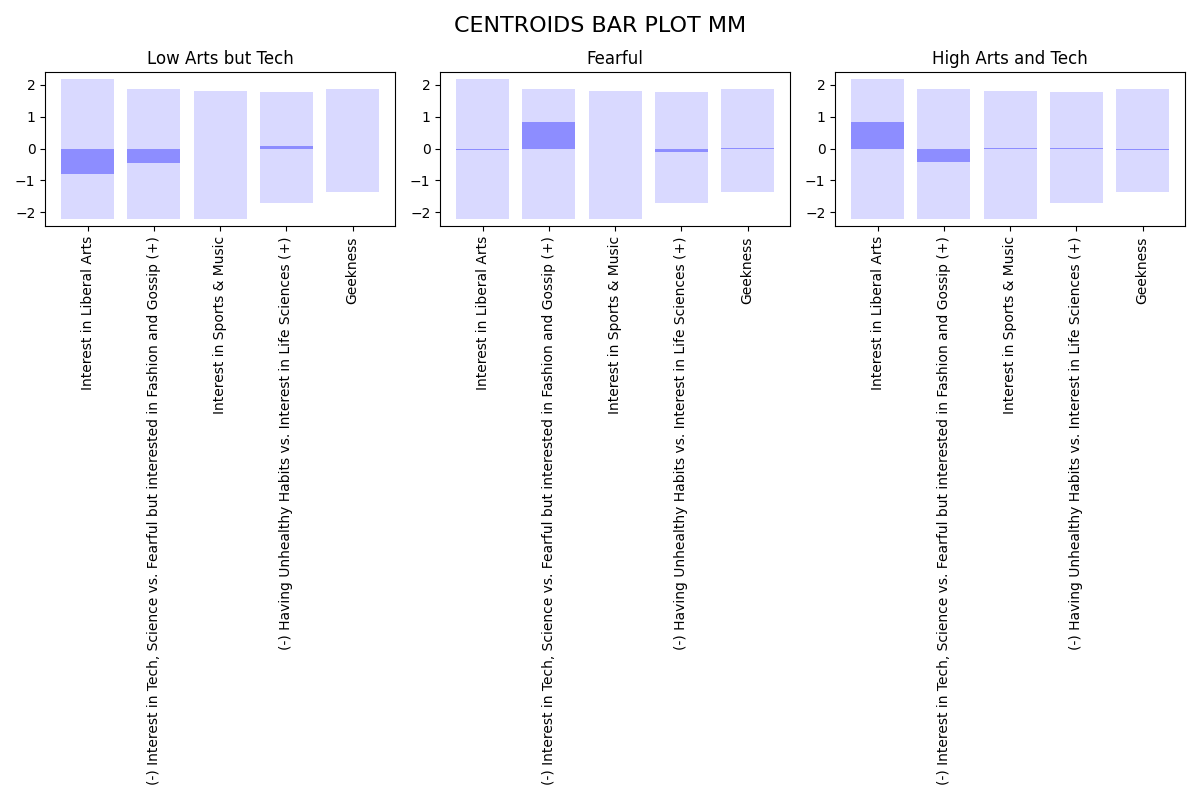

In [103]:
plot_kmeans_centroids(Ymm, mm_km_best, pc_names_mm, clusters_names_mm, title="CENTROIDS BAR PLOT MM")

To proceed with the external evaluation we first have to merge togheter labels and feeding features, in order to group togheter the former, averaging the silhouette score of each label

In [104]:
Ystd_df_with_labels['kmeans-label'] = std_labels_best
Ystd_df_with_labels['silhouette'] = std_sil_samples

In [105]:
Ymm_df_with_labels['kmeans-label'] = mm_labels_best
Ymm_df_with_labels['silhouette'] = mm_sil_samples

### External Evaluation

As can be visually seen in the plots, the cluster have a significant difference in which count of gender belongs to each. With the "Fearful" cluster being mainly compsed by females users, while "High-Tech" cluster mainly populated by males.

In [106]:
def external_evaluation(Y_df, kmeans_label, label, clusters_names):
    # For better visualization
    print(f'┌{"─" * 40}┐')
    print(f'│ {"EXTERNAL EVALUATION":^38} │')
    for cluster_label in np.sort(Y_df[kmeans_label].unique()):
        curr_label_entries = Y_df[Y_df[kmeans_label] == cluster_label]
        
        # For better visualization
        print(f"├{'─' * 40}┤")
        print(f"│ Label {clusters_names[cluster_label]:^16}")
        
        # Display the label value counts
        print(f"{curr_label_entries[label].value_counts()}")
    
    # Final formatting
    print(f'└{"─" * 40}┘')

In [107]:
external_evaluation(Ystd_df_with_labels, 'kmeans-label', 'Gender', clusters_names_std)

┌────────────────────────────────────────┐
│          EXTERNAL EVALUATION           │
├────────────────────────────────────────┤
│ Label Low Arts but Tech
Gender
male      103
female     43
Name: count, dtype: int64
├────────────────────────────────────────┤
│ Label High Arts and Tech
Gender
female    95
male      70
Name: count, dtype: int64
├────────────────────────────────────────┤
│ Label     Fearful     
Gender
female    153
male       20
Name: count, dtype: int64
└────────────────────────────────────────┘


In [108]:
external_evaluation(Ymm_df_with_labels, 'kmeans-label', 'Gender', clusters_names_mm)

┌────────────────────────────────────────┐
│          EXTERNAL EVALUATION           │
├────────────────────────────────────────┤
│ Label Low Arts but Tech
Gender
male      107
female     52
Name: count, dtype: int64
├────────────────────────────────────────┤
│ Label     Fearful     
Gender
female    150
male       16
Name: count, dtype: int64
├────────────────────────────────────────┤
│ Label High Arts and Tech
Gender
female    89
male      70
Name: count, dtype: int64
└────────────────────────────────────────┘


### Internal Evaluation

Silhouette scores grouped for each cluster deviate slightly from the global average silhouette. Nevertheless, on standard scaled data, the class "Fearful", for which we know from previous analysis that is mainly populated by females, appear to be more compact within their cluster, obtaining a higher value in Silhouette score. Furthermore, we notice that the worst perfoming cluster (i.e. lowest silhouette score) is the one associated to "Low Arts but Tech", corresponding to a clustering mainly populated by males.

In [109]:
def print_silhouette_info_by_label(Y_df, label):

    # For better visualization
    print(f'┌{"─" * 40}┐')
    print(f'│ {"INTERNAL EVALUATION":^38} │')
    
    # Loop trought all selected classes in the label 
    for label_class in np.sort(Y_df[label].unique()):

        # Extract entries associated to such label
        curr_label_entries = Y_df[Y_df[label] == label_class]
        
        # For better visualization
        print(f"├{'─' * 40}┤")
        print(f"│ Class {clusters_names_std[label_class]:^16}")
        print(f"│ Avg Silhouette: {curr_label_entries['silhouette'].mean():^8.4f}")
    print(f'└{"─" * 40}┘')

    # For better visualization
    print('\n' + '━' * 42)
    print(f'GLOBAL SILHOUETTE SCORE: {Y_df["silhouette"].mean():>10.4f}')
    print('━' * 42 + '\n')

In [110]:
print_silhouette_info_by_label(Ystd_df_with_labels, 'kmeans-label')

┌────────────────────────────────────────┐
│          INTERNAL EVALUATION           │
├────────────────────────────────────────┤
│ Class Low Arts but Tech
│ Avg Silhouette:  0.1468 
├────────────────────────────────────────┤
│ Class High Arts and Tech
│ Avg Silhouette:  0.1657 
├────────────────────────────────────────┤
│ Class     Fearful     
│ Avg Silhouette:  0.2171 
└────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GLOBAL SILHOUETTE SCORE:     0.1784
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



A different result appear when we look at min-max scaled data. In this case the highest silhouette score is obtained by the class "High Arts and Tech", which in the external evaluation was described by a balanced number of both genders. We must suppose that indeed some differences between the two runs of k-means arised while operating on standard scaled and min-max scaled data respectively. And such difference reflects on how the k-means centroids are positioned with respect to the disposition of the `Gender` lebel itself. 

In [111]:
print_silhouette_info_by_label(Ymm_df_with_labels, 'kmeans-label')

┌────────────────────────────────────────┐
│          INTERNAL EVALUATION           │
├────────────────────────────────────────┤
│ Class Low Arts but Tech
│ Avg Silhouette:  0.1483 
├────────────────────────────────────────┤
│ Class High Arts and Tech
│ Avg Silhouette:  0.2138 
├────────────────────────────────────────┤
│ Class     Fearful     
│ Avg Silhouette:  0.1725 
└────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
GLOBAL SILHOUETTE SCORE:     0.1787
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



## Customer Profiling

Given the data analyzed we are able to profile 3 main types of customers that company should focus on, mainly given by the following cluster (already provided before, reported here again for ease of reading):

1. "Emotional" User
   - High fear towards phobias
   - Strong interest in fashion and gossip
   - Mostly identifying as females
   - Individuals in this group may prioritize emotional and social aspects, show a greater interest in purchasing expensive clothing, and be more susceptible to opinions of their favorite influencers and celebrities.

2. "Techie" User
    - Low interest in liberal arts, artistic or fashion-related domains.
    - Significant interest in technology, science, and STEM in general.
    - Mostly identifying as males, alt ough also the female gender has a significant share or relavance.
    - Users in this group are likely analytical, pragmatic, and focused on problem-solving and engineering. They may lack interest in more creative or abstract topics like Art. But may show a higher interest towards latest high-tech products and innovations. 

3. "Know-it-all" User
    - High interest in liberal arts
    - Also moderate or high interest in STEM.
    - Likely to combine creative and technical skills togheter.
    - Male and Female genders are well-balanced without any of the two statistically prevailing.
    - This group represents interdisciplinary people, interested mainly in artistic fields but also fascinated by technical and science topics. They may be attracted to fields that try to merge both like design.



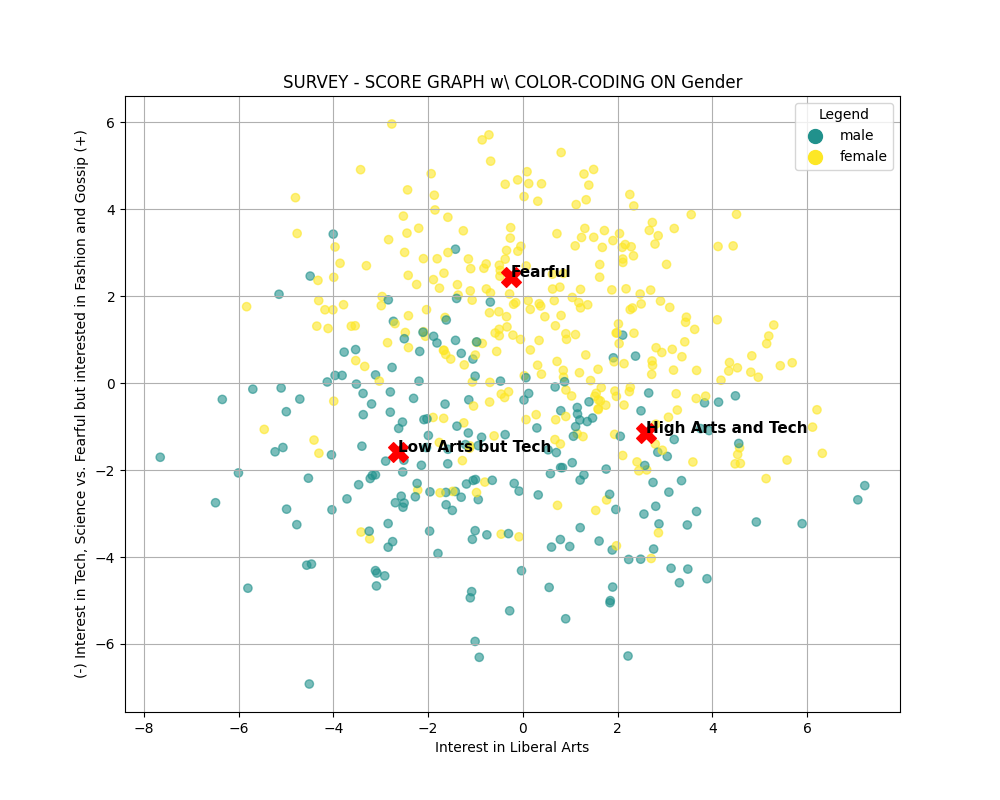

In [112]:
scatter_plot(Ystd_df_with_labels, axis_names=[pc_names_std[0], pc_names_std[1]], label='Gender', cmap='viridis',  km=std_km_best, cluster_names=clusters_names_std, scatter_alpha=0.6, figsize=(10, 8))